# 🏠 House Price Prediction Using Machine Learning

## 📌 Project Overview

This project develops a machine learning system to predict residential house prices based on property characteristics such as area, number of bedrooms, number of bathrooms, property age, location, and property type.

The project demonstrates a complete supervised machine learning workflow, including data understanding, exploratory data analysis, preprocessing, model development, evaluation, comparison, and interpretation.

### 🎯 Objectives

- Understand and explore the house price dataset.
- Identify relationships between property characteristics and house prices.
- Prepare numerical and categorical features for machine learning.
- Implement Linear Regression from scratch to understand the underlying algorithm.
- Build a Linear Regression model using Scikit-learn.
- Evaluate model performance using multiple regression metrics.
- Compare Linear Regression, Polynomial Regression, Decision Tree, and Random Forest models.
- Visualize predicted prices against actual prices.
- Identify the most influential features affecting house prices.
- Derive practical insights from the model results.

### 🤖 Machine Learning Problem

**Type:** Supervised Learning  
**Task:** Regression  
**Target Variable:** `Price`

The model learns from historical house data where the actual selling price is known and uses the learned relationships to predict prices for unseen properties.

### 📊 Dataset

The dataset contains **300 residential property records** with information about property characteristics and their corresponding prices.

### 🛠️ Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

### 📋 Project Workflow

**Data Loading → Data Understanding → Exploratory Data Analysis → Data Preprocessing → Train-Test Split → Model Development → Model Evaluation → Model Comparison → Feature Analysis → Insights & Conclusion**

In [269]:
# ============================================
# 1. IMPORT LIBRARIES
# ============================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Reproducibility
RANDOM_STATE = 42

print("Libraries imported successfully.")
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)

Libraries imported successfully.
NumPy version: 2.2.6
Pandas version: 3.0.1


# 📂 2. Data Loading

The house price dataset is loaded into a Pandas DataFrame for analysis.

The dataset contains residential property information such as area, bedrooms, bathrooms, property age, location, property type, and the corresponding house price.

### Objectives

- Load the dataset successfully.
- Verify the number of observations and features.
- Preview the available records.
- Confirm that the expected dataset has been loaded correctly.

In [270]:
# ============================================
# 2.1 LOAD DATASET
# ============================================

# Load the house price dataset
df = pd.read_csv("house_prices.csv")

print("Dataset loaded successfully!")
print(f"Number of rows    : {df.shape[0]}")
print(f"Number of columns : {df.shape[1]}")

display(df.head())

Dataset loaded successfully!
Number of rows    : 300
Number of columns : 8


,Property_ID,Area,Bedrooms,Bathrooms,Age,Location,Property_Type,Price
0,PROP0001,3712,4,3,36,Rural,House,22260000
1,PROP0002,1591,4,1,35,Suburb,House,16057500
2,PROP0003,1646,4,3,20,Rural,Villa,12730000
3,PROP0004,4814,1,2,13,City Center,Villa,50840000
4,PROP0005,800,4,2,38,Suburb,Apartment,10650000


## 🔍 2.2 Initial Dataset Preview

Before performing exploratory analysis or machine learning, the dataset is examined to understand its structure, variables, data types, and overall data quality.

This initial inspection helps identify potential issues such as missing values, duplicate records, inappropriate data types, identifier columns, and unusual feature distributions.

### Initial Inspection Goals

- Examine the dataset dimensions.
- Identify all available features.
- Determine the data type of each variable.
- Inspect summary statistics for numerical variables.
- Check for missing values and duplicate records.
- Distinguish identifier variables from predictive features.

In [271]:
# ============================================
# 2.2 INITIAL DATASET INSPECTION
# ============================================

# Dataset dimensions
print("Dataset Shape:")
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

# Column names
print("\nColumn Names:")
print(df.columns.tolist())

# Data types
print("\nData Types:")
display(df.dtypes.to_frame(name="Data Type"))

# Dataset information
print("\nDataset Information:")
df.info()

Dataset Shape:
Rows    : 300
Columns : 8

Column Names:
['Property_ID', 'Area', 'Bedrooms', 'Bathrooms', 'Age', 'Location', 'Property_Type', 'Price']

Data Types:


,Data Type
Property_ID,str
Area,int64
Bedrooms,int64
Bathrooms,int64
Age,int64
Location,str
Property_Type,str
Price,int64



Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Property_ID    300 non-null    str  
 1   Area           300 non-null    int64
 2   Bedrooms       300 non-null    int64
 3   Bathrooms      300 non-null    int64
 4   Age            300 non-null    int64
 5   Location       300 non-null    str  
 6   Property_Type  300 non-null    str  
 7   Price          300 non-null    int64
dtypes: int64(5), str(3)
memory usage: 18.9 KB


### 📊 2.3 Descriptive Statistics

Descriptive statistics are used to understand the distribution and scale of the numerical variables.

The analysis includes the mean, standard deviation, minimum, maximum, and quartile values. These statistics provide an initial indication of variability, potential extreme observations, and differences in scale across the numerical features.

In [272]:
# ============================================
# 2.3 DESCRIPTIVE STATISTICS
# ============================================

# Generate descriptive statistics for numerical variables
descriptive_stats = df.describe().T

# Add coefficient of variation for additional insight
descriptive_stats["CV (%)"] = (
    descriptive_stats["std"] / descriptive_stats["mean"] * 100
).round(2)

display(descriptive_stats)

,count,mean,std,min,25%,50%,75%,max,CV (%)
Area,300.00,"2,759.70","1,297.68",520.00,"1,675.75","2,738.00","3,801.25","4,999.00",47.02
Bedrooms,300.00,3.03,1.47,1.00,2.00,3.00,4.00,5.00,48.37
Bathrooms,300.00,2.03,0.79,1.00,1.00,2.00,3.00,3.00,39.10
Age,300.00,25.00,14.33,0.00,12.00,25.50,36.25,49.00,57.33
Price,300.00,"24,883,658.33","12,665,254.72","3,695,000.00","15,277,500.00","22,365,000.00","34,608,125.00","58,700,000.00",50.90


### 🧹 2.4 Data Quality Assessment

Before proceeding to exploratory analysis and model development, the dataset is evaluated for potential data-quality issues.

The assessment covers:

- Missing values
- Duplicate records
- Unique-value counts
- Potential identifier variables

A clean and correctly structured dataset is essential for producing reliable exploratory analysis and machine learning models.

In [273]:
# ============================================
# 2.4 DATA QUALITY ASSESSMENT
# ============================================

# Missing-value analysis
missing_analysis = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage (%)": (df.isnull().mean() * 100).round(2)
})

print("Missing Value Analysis")
display(missing_analysis)

# Duplicate analysis
duplicate_count = df.duplicated().sum()

print(f"Duplicate Records: {duplicate_count}")

# Unique-value analysis
unique_analysis = pd.DataFrame({
    "Unique Values": df.nunique(),
    "Data Type": df.dtypes.astype(str)
})

print("\nUnique Value Analysis")
display(unique_analysis)

# Identify potential identifier columns
identifier_columns = [
    column for column in df.columns
    if df[column].nunique() == len(df)
]

print("\nPotential Identifier Columns:")
for column in identifier_columns:
    print(f"- {column}")

Missing Value Analysis


,Missing Count,Missing Percentage (%)
Property_ID,0,0.00
Area,0,0.00
Bedrooms,0,0.00
Bathrooms,0,0.00
Age,0,0.00
Location,0,0.00
Property_Type,0,0.00
Price,0,0.00


Duplicate Records: 0

Unique Value Analysis


,Unique Values,Data Type
Property_ID,300,str
Area,290,int64
Bedrooms,5,int64
Bathrooms,3,int64
Age,50,int64
Location,3,str
Property_Type,3,str
Price,296,int64



Potential Identifier Columns:
- Property_ID


### 🧠 2.5 Initial Data Quality Findings

The initial inspection indicates that the dataset is structurally clean and suitable for exploratory analysis and subsequent machine learning.

- The dataset contains **300 observations and 8 variables**.
- No missing values were detected in any feature, eliminating the need for missing-value imputation.
- No duplicate records were identified.
- `Property_ID` contains a unique value for every observation and therefore functions as an identifier rather than a predictive feature. It will be excluded from model training.
- `Location` and `Property_Type` are categorical variables that will require appropriate encoding before machine learning.
- The numerical variables exhibit meaningful variation, particularly `Area`, `Age`, and `Price`.
- House prices range from approximately **₹3.70 million to ₹58.70 million**, indicating a substantial range in property values.
- The relatively high coefficient of variation for several numerical variables suggests that distributional analysis and potential outlier investigation are warranted before model development.

These findings establish the foundation for the exploratory data analysis phase.

# 📊 3. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand the distributions, relationships, and patterns within the house price dataset.

The analysis focuses on:

- Distribution of the target variable (`Price`)
- Distribution of numerical features
- Relationships between property characteristics and price
- Categorical differences in property prices
- Correlation between numerical variables
- Potential outliers and unusual observations

Each visualization is accompanied by an interpretation to connect the observed patterns with the house price prediction problem.

## 💰 3.1 Distribution of House Prices

The distribution of the target variable, `Price`, is examined to understand the range, central tendency, and spread of house prices.

Understanding the target distribution is important because highly skewed or irregular target values can influence regression model performance.

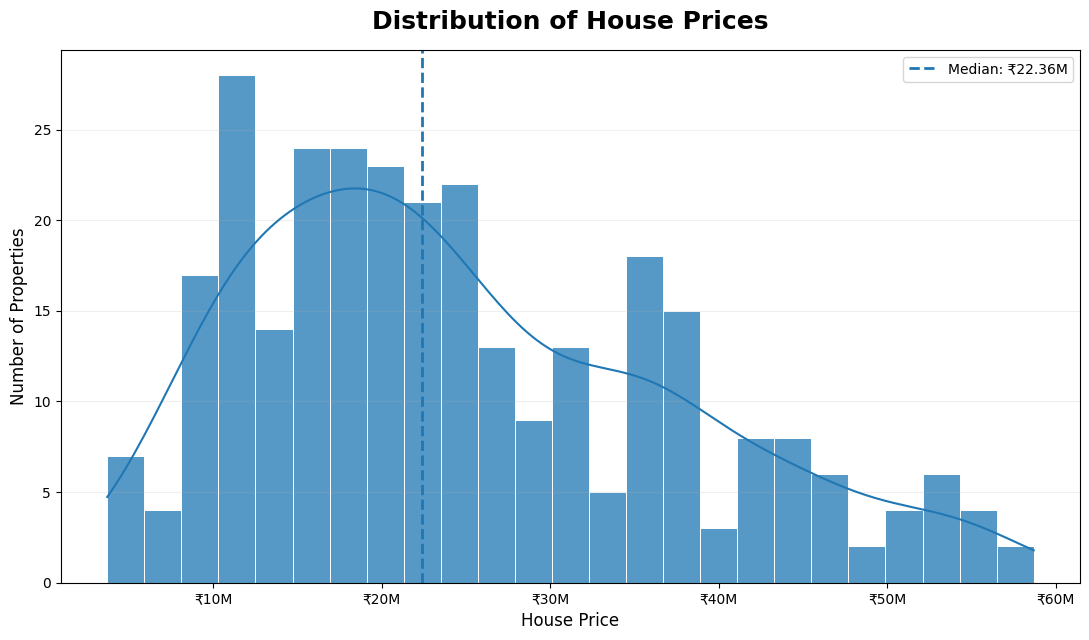

In [274]:
# ============================================
# 3.1 PRICE DISTRIBUTION — ENHANCED
# ============================================

plt.figure(figsize=(11, 6.5))

# Histogram with KDE
sns.histplot(
    data=df,
    x="Price",
    bins=25,
    kde=True,
    alpha=0.75,
    edgecolor="white",
    linewidth=0.7
)

# Median reference line
median_price = df["Price"].median()

plt.axvline(
    median_price,
    linestyle="--",
    linewidth=2,
    label=f"Median: ₹{median_price / 1e6:.2f}M"
)

# Format x-axis in millions
ax = plt.gca()
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, pos: f"₹{x/1e6:.0f}M")
)

plt.title(
    "Distribution of House Prices",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel("House Price", fontsize=12)
plt.ylabel("Number of Properties", fontsize=12)

plt.legend(frameon=True)
plt.grid(axis="y", alpha=0.2)

plt.tight_layout()

# Save high-resolution visualization
plt.savefig(
    "visualizations/01_price_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 🧠 Interpretation — House Price Distribution

The house price distribution shows considerable variability across the 300 properties.

Most observations are concentrated in the lower-to-middle price range, while a smaller number of properties extend toward substantially higher prices. This creates a noticeable right-side tail in the distribution, indicating that the target variable is not perfectly symmetric.

The observed spread is consistent with the descriptive statistics, where house prices range from approximately ₹3.70 million to ₹58.70 million.

The higher-priced observations should not automatically be treated as errors or removed. Their values may be associated with differences in property characteristics such as area, location, or property type. These relationships will therefore be investigated in subsequent EDA rather than applying arbitrary outlier removal.

**Analytical implication:**  
Because the target variable has substantial variation and some right-skewness, model performance should be evaluated using multiple metrics rather than relying on a single measure.

## 📐 3.2 Distribution Statistics and Outlier Assessment

The distribution of the target variable is quantified using skewness and the Interquartile Range (IQR).

Skewness helps measure the asymmetry of the distribution, while the IQR-based analysis identifies observations that fall substantially beyond the central 50% of the data.

These observations will be investigated rather than automatically removed.

In [275]:
# ============================================
# 3.2 PRICE DISTRIBUTION STATISTICS
# ============================================

price_skewness = df["Price"].skew()

Q1 = df["Price"].quantile(0.25)
Q3 = df["Price"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

potential_outliers = df[
    (df["Price"] < lower_bound) |
    (df["Price"] > upper_bound)
]

print(f"Price Skewness : {price_skewness:.3f}")
print(f"Q1             : ₹{Q1:,.0f}")
print(f"Q3             : ₹{Q3:,.0f}")
print(f"IQR            : ₹{IQR:,.0f}")
print(f"Lower Bound    : ₹{lower_bound:,.0f}")
print(f"Upper Bound    : ₹{upper_bound:,.0f}")
print(f"Potential Outliers: {len(potential_outliers)}")

Price Skewness : 0.659
Q1             : ₹15,277,500
Q3             : ₹34,608,125
IQR            : ₹19,330,625
Lower Bound    : ₹-13,718,438
Upper Bound    : ₹63,604,062
Potential Outliers: 0


In [276]:
# ============================================
# SAVE PRICE DISTRIBUTION STATISTICS
# ============================================

price_statistics = pd.DataFrame({
    "Metric": [
        "Skewness",
        "Q1",
        "Median",
        "Q3",
        "IQR",
        "Lower Bound",
        "Upper Bound",
        "Potential Outliers"
    ],
    "Value": [
        price_skewness,
        Q1,
        df["Price"].median(),
        Q3,
        IQR,
        lower_bound,
        upper_bound,
        len(potential_outliers)
    ]
})

price_statistics.to_csv(
    "results/price_distribution_statistics.csv",
    index=False
)

print("Price distribution statistics saved successfully.")

Price distribution statistics saved successfully.


## 📈 3.3 Area vs. House Price

Area is expected to be an important predictor of residential property prices.

A scatter plot with a fitted regression trend is used to examine the direction, strength, and approximate linearity of the relationship between property area and price.

The analysis will also quantify the relationship using Pearson correlation rather than relying solely on visual inspection.

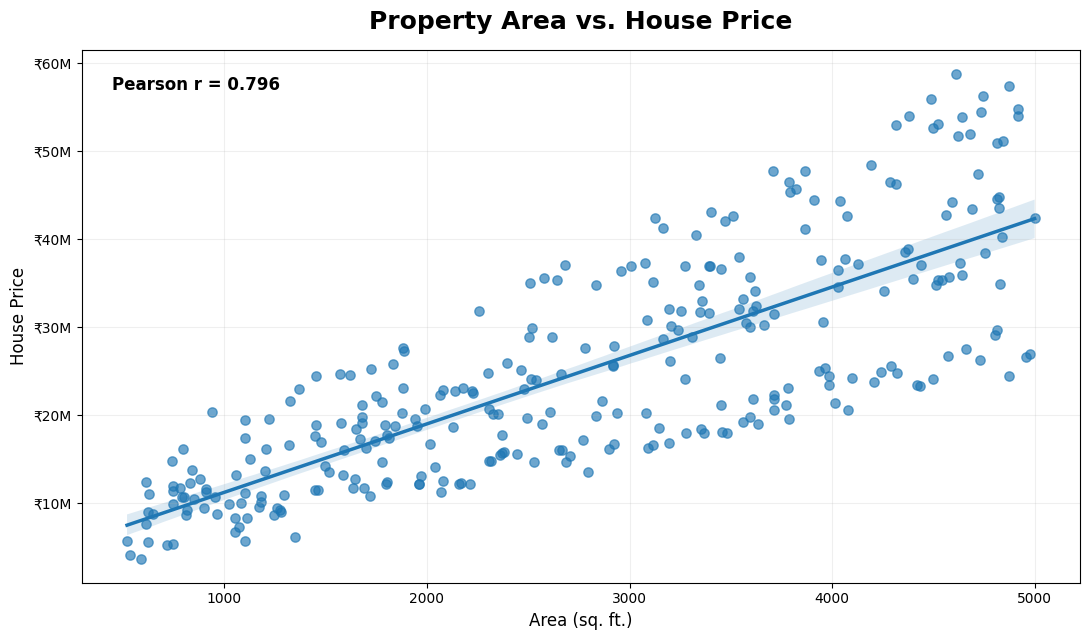

In [277]:
# ============================================
# 3.3 AREA VS PRICE — ENHANCED
# ============================================

# Calculate Pearson correlation
area_price_correlation = df["Area"].corr(df["Price"])

plt.figure(figsize=(11, 6.5))

sns.regplot(
    data=df,
    x="Area",
    y="Price",
    scatter_kws={"alpha": 0.65, "s": 45},
    line_kws={"linewidth": 2.5}
)

# Add correlation annotation
plt.text(
    0.03,
    0.95,
    f"Pearson r = {area_price_correlation:.3f}",
    transform=plt.gca().transAxes,
    fontsize=12,
    fontweight="bold",
    verticalalignment="top"
)

plt.title(
    "Property Area vs. House Price",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel("Area (sq. ft.)", fontsize=12)
plt.ylabel("House Price", fontsize=12)

# Format price axis in millions
ax = plt.gca()
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, pos: f"₹{x/1e6:.0f}M")
)

plt.grid(alpha=0.2)
plt.tight_layout()

plt.savefig(
    "visualizations/02_area_vs_price.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [278]:
# ============================================
# SAVE AREA-PRICE CORRELATION
# ============================================

area_price_result = pd.DataFrame({
    "Analysis": ["Area vs Price"],
    "Pearson_Correlation": [area_price_correlation]
})

area_price_result.to_csv(
    "results/area_price_correlation.csv",
    index=False
)

print("Area-price correlation saved successfully.")

Area-price correlation saved successfully.


### 🧠 Interpretation — Area and House Price

The analysis reveals a **strong positive relationship** between property area and house price, with a Pearson correlation coefficient of **0.796**.

The scatter plot shows that larger properties generally tend to have higher prices, and the fitted regression line confirms the overall upward trend.

However, the observations are not perfectly aligned with the regression line. Properties with similar areas can have noticeably different prices, suggesting that other factors such as location, property type, bedrooms, bathrooms, and age also contribute to price variation.

**Analytical implication:**  
Area is expected to be an important predictive feature for the machine learning models. However, its correlation with price is not sufficiently strong to explain the entire variation in house prices, supporting the need to incorporate multiple features into the regression models.

## 📊 3.4 Bedrooms & Bathrooms vs. House Price

Bedrooms and bathrooms represent important structural characteristics of a residential property.

This analysis compares the average house price across different bedroom and bathroom counts to determine whether properties with additional rooms tend to have higher prices.

Mean prices are examined alongside the number of observations in each group to avoid interpreting small groups without sufficient context.

In [279]:
# ============================================
# 3.4 BEDROOMS & BATHROOMS VS PRICE
# ============================================

# Calculate grouped statistics
bedroom_analysis = (
    df.groupby("Bedrooms")["Price"]
    .agg(["mean", "median", "count"])
    .reset_index()
)

bathroom_analysis = (
    df.groupby("Bathrooms")["Price"]
    .agg(["mean", "median", "count"])
    .reset_index()
)

# Combine results for saving
bedroom_analysis["Feature"] = "Bedrooms"
bedroom_analysis = bedroom_analysis.rename(
    columns={"Bedrooms": "Category"}
)

bathroom_analysis["Feature"] = "Bathrooms"
bathroom_analysis = bathroom_analysis.rename(
    columns={"Bathrooms": "Category"}
)

room_price_analysis = pd.concat(
    [bedroom_analysis, bathroom_analysis],
    ignore_index=True
)

room_price_analysis = room_price_analysis[
    ["Feature", "Category", "mean", "median", "count"]
]

display(room_price_analysis)

,Feature,Category,mean,median,count
0,Bedrooms,1,"22,514,571.43","19,360,000.00",70
1,Bedrooms,2,"23,198,586.96","20,967,500.00",46
2,Bedrooms,3,"20,912,295.92","18,840,000.00",49
3,Bedrooms,4,"27,048,209.46","24,562,500.00",74
4,Bedrooms,5,"29,437,254.10","27,445,000.00",61
5,Bathrooms,1,"25,378,972.22","23,090,000.00",90
6,Bathrooms,2,"24,898,950.89","22,052,500.00",112
7,Bathrooms,3,"24,411,301.02","22,458,750.00",98


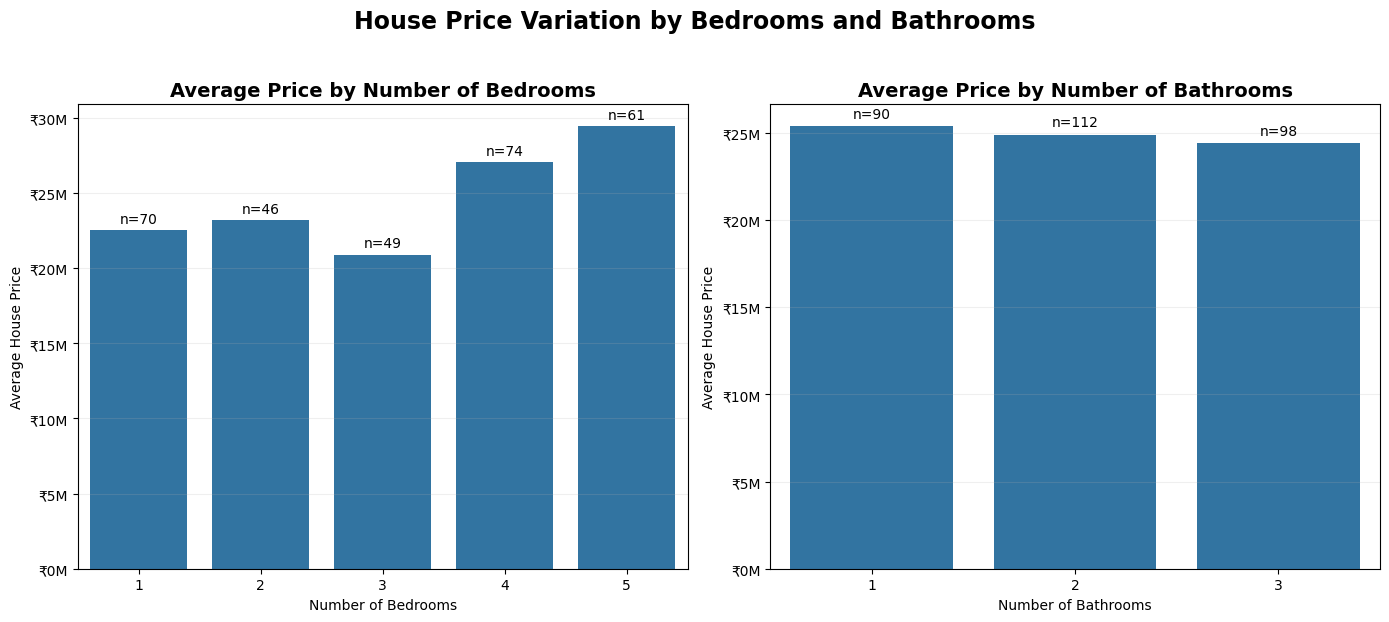

In [280]:
# ============================================
# 3.4 BEDROOMS & BATHROOMS VS PRICE — ENHANCED
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --------------------------------------------
# Bedrooms
# --------------------------------------------

sns.barplot(
    data=bedroom_analysis,
    x="Category",
    y="mean",
    ax=axes[0]
)

axes[0].set_title(
    "Average Price by Number of Bedrooms",
    fontsize=14,
    fontweight="bold"
)

axes[0].set_xlabel("Number of Bedrooms")
axes[0].set_ylabel("Average House Price")

# Add observation counts
for i, row in bedroom_analysis.iterrows():
    axes[0].text(
        i,
        row["mean"] + 500000,
        f"n={int(row['count'])}",
        ha="center",
        fontsize=10
    )


# --------------------------------------------
# Bathrooms
# --------------------------------------------

sns.barplot(
    data=bathroom_analysis,
    x="Category",
    y="mean",
    ax=axes[1]
)

axes[1].set_title(
    "Average Price by Number of Bathrooms",
    fontsize=14,
    fontweight="bold"
)

axes[1].set_xlabel("Number of Bathrooms")
axes[1].set_ylabel("Average House Price")

# Add observation counts
for i, row in bathroom_analysis.iterrows():
    axes[1].text(
        i,
        row["mean"] + 500000,
        f"n={int(row['count'])}",
        ha="center",
        fontsize=10
    )


# --------------------------------------------
# Formatting
# --------------------------------------------

for ax in axes:
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, pos: f"₹{x/1e6:.0f}M")
    )
    ax.grid(axis="y", alpha=0.2)

plt.suptitle(
    "House Price Variation by Bedrooms and Bathrooms",
    fontsize=17,
    fontweight="bold",
    y=1.03
)

plt.tight_layout()

plt.savefig(
    "visualizations/03_bedrooms_bathrooms_vs_price.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [281]:
# ============================================
# SAVE BEDROOM/BATHROOM ANALYSIS
# ============================================

room_price_analysis.to_csv(
    "results/bedrooms_bathrooms_price_analysis.csv",
    index=False
)

print("Bedroom and bathroom price analysis saved successfully.")

Bedroom and bathroom price analysis saved successfully.


## 📍 3.5 Location & Property Type vs. House Price

Location and property type are categorical characteristics that may influence residential property prices.

This analysis compares house prices across different locations and property types using group-level statistics. Both the average and median prices are examined because the mean can be influenced by relatively high-priced properties.

The number of observations in each category is also reported to provide context for the comparisons.

In [282]:
# ============================================
# 3.5 LOCATION & PROPERTY TYPE ANALYSIS
# ============================================

# Location-level analysis
location_analysis = (
    df.groupby("Location")["Price"]
    .agg(["mean", "median", "count"])
    .reset_index()
)

# Property-type analysis
property_type_analysis = (
    df.groupby("Property_Type")["Price"]
    .agg(["mean", "median", "count"])
    .reset_index()
)

print("Location-wise Price Statistics")
display(location_analysis)

print("\nProperty-Type-wise Price Statistics")
display(property_type_analysis)

Location-wise Price Statistics


,Location,mean,median,count
0,City Center,"33,149,793.81","34,970,000.00",97
1,Rural,"16,461,428.57","16,052,500.00",98
2,Suburb,"25,108,071.43","24,030,000.00",105



Property-Type-wise Price Statistics


,Property_Type,mean,median,count
0,Apartment,"27,124,203.30","25,642,500.00",91
1,House,"22,876,915.89","20,575,000.00",107
2,Villa,"24,989,852.94","21,810,000.00",102


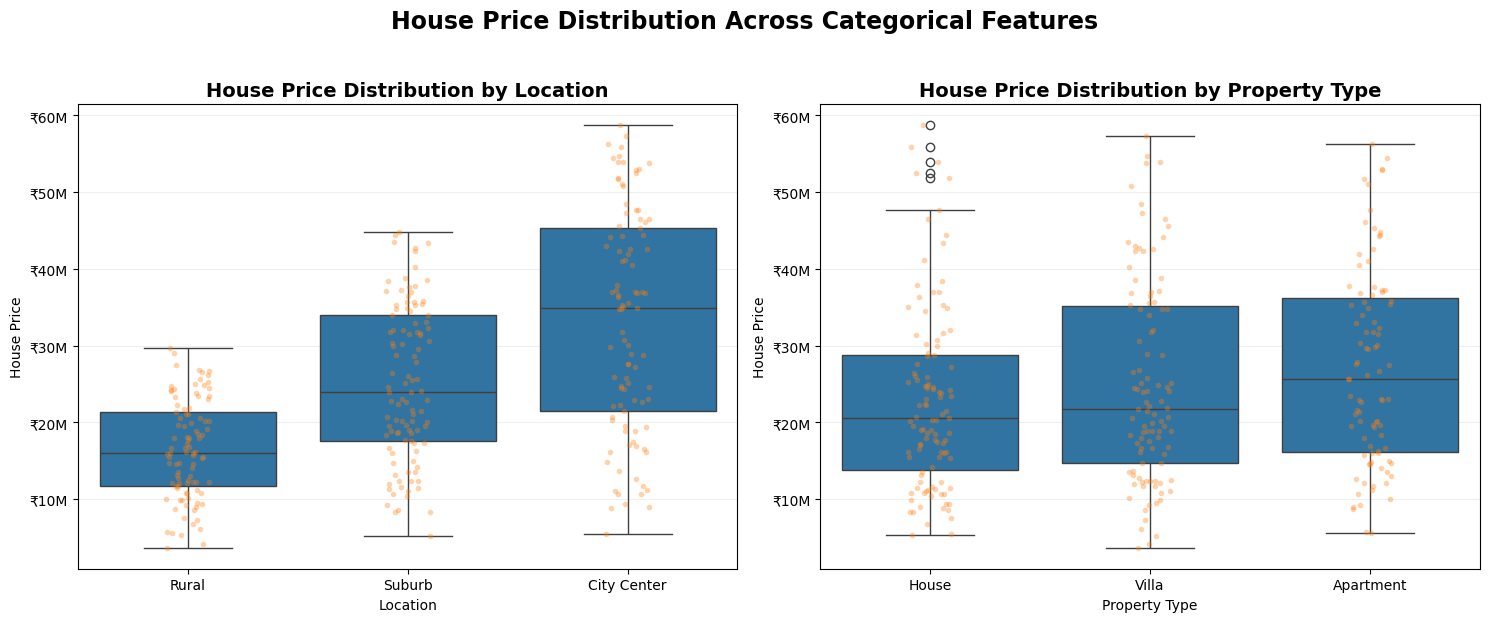

In [283]:
# ============================================
# 3.5 LOCATION & PROPERTY TYPE — DISTRIBUTION
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --------------------------------------------
# Location Price Distribution
# --------------------------------------------

sns.boxplot(
    data=df,
    x="Location",
    y="Price",
    ax=axes[0],
    showfliers=True
)

sns.stripplot(
    data=df,
    x="Location",
    y="Price",
    ax=axes[0],
    alpha=0.35,
    jitter=True,
    size=4
)

axes[0].set_title(
    "House Price Distribution by Location",
    fontsize=14,
    fontweight="bold"
)

axes[0].set_xlabel("Location")
axes[0].set_ylabel("House Price")


# --------------------------------------------
# Property Type Price Distribution
# --------------------------------------------

sns.boxplot(
    data=df,
    x="Property_Type",
    y="Price",
    ax=axes[1],
    showfliers=True
)

sns.stripplot(
    data=df,
    x="Property_Type",
    y="Price",
    ax=axes[1],
    alpha=0.35,
    jitter=True,
    size=4
)

axes[1].set_title(
    "House Price Distribution by Property Type",
    fontsize=14,
    fontweight="bold"
)

axes[1].set_xlabel("Property Type")
axes[1].set_ylabel("House Price")


# --------------------------------------------
# Formatting
# --------------------------------------------

for ax in axes:
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, pos: f"₹{x/1e6:.0f}M")
    )
    ax.grid(axis="y", alpha=0.2)

plt.suptitle(
    "House Price Distribution Across Categorical Features",
    fontsize=17,
    fontweight="bold",
    y=1.03
)

plt.tight_layout()

plt.savefig(
    "visualizations/04_location_property_type_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [284]:
# ============================================
# SAVE LOCATION & PROPERTY TYPE RESULTS
# ============================================

location_results = location_analysis.copy()
location_results.insert(0, "Feature", "Location")
location_results = location_results.rename(
    columns={"Location": "Category"}
)

property_results = property_type_analysis.copy()
property_results.insert(0, "Feature", "Property Type")
property_results = property_results.rename(
    columns={"Property_Type": "Category"}
)

categorical_price_results = pd.concat(
    [location_results, property_results],
    ignore_index=True
)

categorical_price_results = categorical_price_results[
    ["Feature", "Category", "mean", "median", "count"]
]

# Add readable column names
categorical_price_results = categorical_price_results.rename(
    columns={
        "mean": "Average Price",
        "median": "Median Price",
        "count": "Number of Properties"
    }
)

display(categorical_price_results)

categorical_price_results.to_csv(
    "results/location_property_type_price_analysis.csv",
    index=False
)

print("Location and property-type results saved successfully.")

,Feature,Category,Average Price,Median Price,Number of Properties
0,Location,City Center,"33,149,793.81","34,970,000.00",97
1,Location,Rural,"16,461,428.57","16,052,500.00",98
2,Location,Suburb,"25,108,071.43","24,030,000.00",105
3,Property Type,Apartment,"27,124,203.30","25,642,500.00",91
4,Property Type,House,"22,876,915.89","20,575,000.00",107
5,Property Type,Villa,"24,989,852.94","21,810,000.00",102


Location and property-type results saved successfully.


### 🧠 Interpretation — Location and Property Type Price Distributions

The distribution of house prices differs substantially across locations. Rural properties have the lowest central price level, while City Center properties exhibit the highest median prices and a considerably wider upper distribution. Suburban properties occupy an intermediate position.

The individual observations also reveal substantial within-location variation, indicating that location alone does not completely determine house prices.

Across property types, the distributions overlap considerably. Apartments show a somewhat higher median price than Villas and Houses, but the differences are considerably less pronounced than the differences observed across locations.

Several higher-priced observations are visible across the categorical groups. However, their presence within the distributions indicates that they should be investigated in combination with other property characteristics rather than automatically removed as outliers.

**Analytical implication:**  
Location appears to provide stronger discriminatory information about house prices than Property Type at the univariate level. Both categorical variables will nevertheless be retained for model development because their predictive contribution may change when considered jointly with numerical features.

## 📉 3.6 Property Age vs. House Price

Property age may influence house prices because newer and older properties can differ in condition, construction quality, and market appeal.

A density-based visualization is used to examine the relationship between property age and price while reducing the visual overlap that can occur in a conventional scatter plot.

Pearson correlation is also calculated to quantify the strength and direction of the linear relationship.

Pearson Correlation (Age vs Price): -0.131


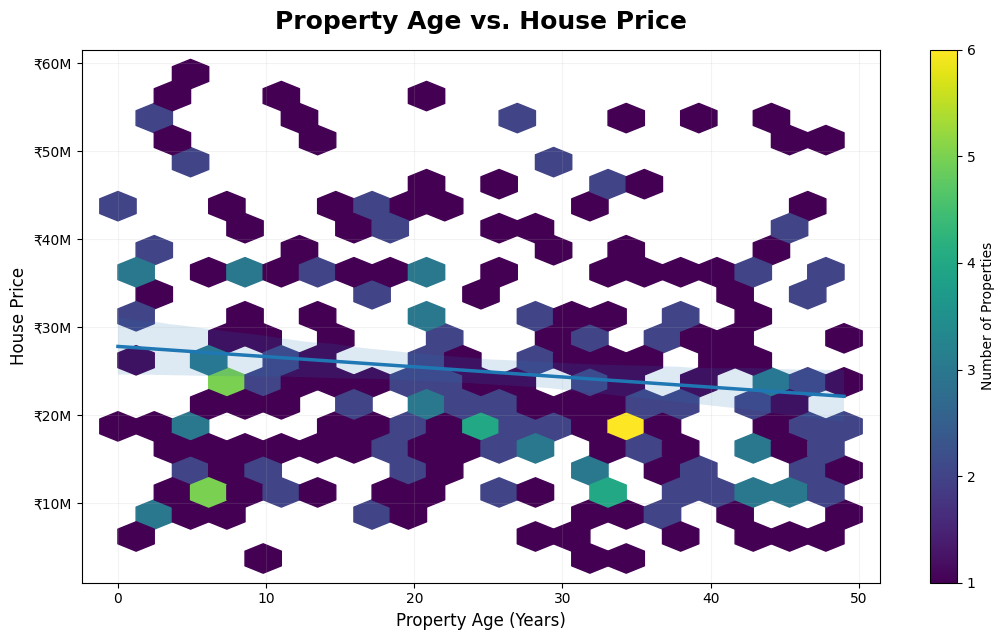

In [285]:
# ============================================
# 3.6 AGE VS PRICE
# ============================================

age_price_correlation = df["Age"].corr(df["Price"])

print(f"Pearson Correlation (Age vs Price): {age_price_correlation:.3f}")

plt.figure(figsize=(11, 6.5))

plt.hexbin(
    df["Age"],
    df["Price"],
    gridsize=20,
    mincnt=1
)

# Regression trend
sns.regplot(
    data=df,
    x="Age",
    y="Price",
    scatter=False,
    line_kws={"linewidth": 2.5}
)

plt.colorbar(label="Number of Properties")

plt.title(
    "Property Age vs. House Price",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel("Property Age (Years)", fontsize=12)
plt.ylabel("House Price", fontsize=12)

ax = plt.gca()

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, pos: f"₹{x/1e6:.0f}M")
)

plt.grid(alpha=0.15)
plt.tight_layout()

plt.savefig(
    "visualizations/05_age_vs_price.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [286]:
# ============================================
# SAVE AGE-PRICE CORRELATION
# ============================================

age_price_result = pd.DataFrame({
    "Analysis": ["Age vs Price"],
    "Metric": ["Pearson Correlation"],
    "Value": [round(age_price_correlation, 4)]
})

display(age_price_result)

age_price_result.to_csv(
    "results/age_price_correlation.csv",
    index=False
)

print("Age-price correlation saved successfully.")

,Analysis,Metric,Value
0,Age vs Price,Pearson Correlation,-0.13


Age-price correlation saved successfully.


### 🧠 Interpretation — Property Age and House Price

The relationship between property age and house price is weakly negative, with a Pearson correlation coefficient of **−0.131**.

The density-based visualization shows substantial price variation across nearly the entire property-age range. Although the fitted regression line has a slight downward slope, the weak correlation indicates that property age alone provides limited information for explaining house-price variation.

The broad vertical dispersion of prices at similar ages further suggests that other characteristics, such as area, location, bedrooms, bathrooms, and property type, play more substantial roles in determining price.

**Analytical implication:**  
Property age may provide some incremental predictive information, but it is unlikely to be a dominant standalone predictor. It will nevertheless be retained as a candidate feature and evaluated alongside the other variables during model development.

## 🔥 3.7 Numerical Feature Correlation Analysis

Correlation analysis is used to examine the strength and direction of linear relationships among the numerical variables.

The analysis includes the predictor variables and the target variable (`Price`). This helps identify potentially important predictors, detect relationships between explanatory variables, and provide an initial indication of multicollinearity before model development.

Pearson correlation coefficients are visualized using a heatmap for easier comparison.

Numerical Correlation Matrix:


,Area,Bedrooms,Bathrooms,Age,Price
Area,1.00,-0.00,-0.03,-0.08,0.80
Bedrooms,-0.00,1.00,-0.04,-0.03,0.20
Bathrooms,-0.03,-0.04,1.00,0.12,-0.03
Age,-0.08,-0.03,0.12,1.00,-0.13
Price,0.80,0.20,-0.03,-0.13,1.00


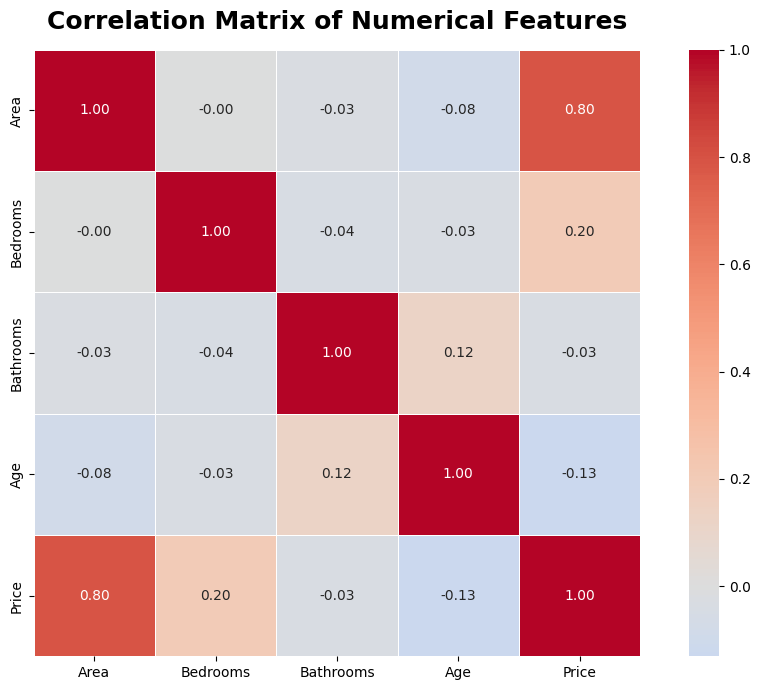

In [287]:
# ============================================
# 3.7 NUMERICAL CORRELATION HEATMAP
# ============================================

# Select numerical variables
numerical_columns = [
    "Area",
    "Bedrooms",
    "Bathrooms",
    "Age",
    "Price"
]

correlation_matrix = df[numerical_columns].corr()

print("Numerical Correlation Matrix:")
display(correlation_matrix.round(3))

# Create heatmap
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True
)

plt.title(
    "Correlation Matrix of Numerical Features",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.tight_layout()

plt.savefig(
    "visualizations/06_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [288]:
# ============================================
# SAVE CORRELATION MATRIX
# ============================================

correlation_matrix.round(4).to_csv(
    "results/numerical_correlation_matrix.csv"
)

print("Correlation matrix saved successfully.")

Correlation matrix saved successfully.


### 🧠 Interpretation — Numerical Correlation Analysis

The correlation matrix indicates that `Area` has the strongest linear association with the target variable, `Price`, with a Pearson correlation of approximately **0.80**. This confirms the strong relationship identified earlier through the Area-versus-Price scatter plot.

`Bedrooms` shows a relatively weak positive correlation with `Price` (approximately **0.20**), while `Age` has a weak negative correlation of approximately **−0.13**. `Bathrooms` has almost no linear correlation with `Price` (approximately **−0.03**).

The correlations among the numerical predictor variables are also very low. The largest predictor-to-predictor correlation is only approximately **0.12** between `Bathrooms` and `Age`.

Therefore, the numerical features do not exhibit evidence of severe pairwise multicollinearity based on Pearson correlation. All numerical predictors can consequently be retained for subsequent model development, subject to further evaluation during preprocessing and model validation.

**Key analytical finding:**  
`Area` is the strongest numerical candidate for predicting house prices, while the remaining numerical variables may provide additional predictive information when combined with categorical features.

## 📍 3.8 Area–Price Relationship by Location

The overall analysis established a strong positive relationship between property area and house price. However, location may influence this relationship because properties with similar areas can have substantially different market values depending on their location.

This analysis therefore examines the Area–Price relationship separately across locations using a grouped scatter plot with fitted regression trends.

The visualization helps determine whether location shifts the price level or changes the strength of the area-price relationship.

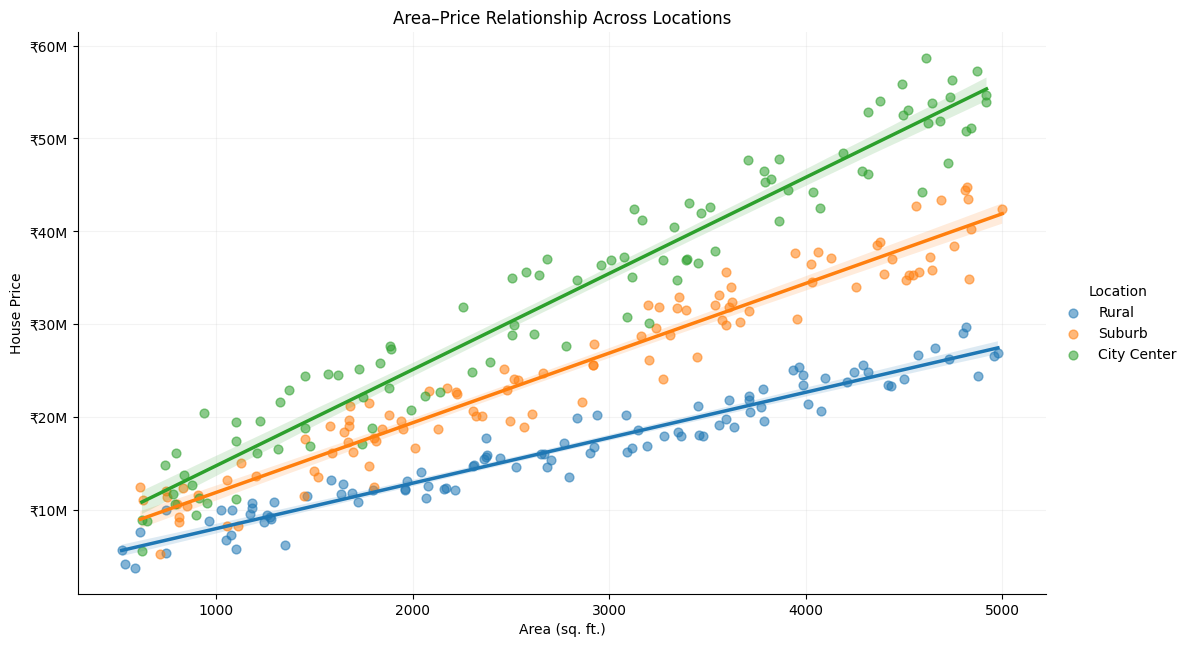

In [289]:
# ============================================
# 3.8 AREA VS PRICE BY LOCATION — FINAL
# ============================================

location_correlations = (
    df.groupby("Location")
    .apply(lambda group: group["Area"].corr(group["Price"]))
    .reset_index(name="Pearson Correlation")
)

location_correlations["Pearson Correlation"] = (
    location_correlations["Pearson Correlation"].round(4)
)

# Create grouped regression visualization
g = sns.lmplot(
    data=df,
    x="Area",
    y="Price",
    hue="Location",
    height=6.5,
    aspect=1.6,
    scatter_kws={"alpha": 0.55, "s": 40},
    line_kws={"linewidth": 2.5}
)

g.set_axis_labels(
    "Area (sq. ft.)",
    "House Price"
)

g.set(
    title="Area–Price Relationship Across Locations"
)

# Format y-axis
g.ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, pos: f"₹{x/1e6:.0f}M")
)

g.ax.grid(alpha=0.15)

# Save the actual lmplot figure
g.savefig(
    "visualizations/07_area_price_by_location.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [290]:
# ============================================
# SAVE LOCATION-WISE CORRELATIONS
# ============================================

location_correlations.to_csv(
    "results/area_price_correlation_by_location.csv",
    index=False
)

print("Location-wise area-price correlations saved successfully.")

Location-wise area-price correlations saved successfully.


### 🧠 Interpretation — Area–Price Relationship Across Locations

The relationship between property area and house price remains extremely strong within each location category, with Pearson correlations of approximately **0.97** for City Center, Rural, and Suburb properties.

The visualization shows that all three locations exhibit a strong positive Area–Price relationship. However, the regression lines are positioned at noticeably different price levels. For a similar property area, City Center properties generally command higher prices, while Rural properties tend to have lower prices.

This indicates that location does not simply determine the strength of the Area–Price relationship; it also appears to shift the overall price level.

The consistent within-location relationships suggest that `Area` is a highly informative predictor, while `Location` provides additional information that cannot be captured by area alone.

**Analytical implication:**  
The findings provide strong motivation for a multivariable regression approach incorporating both numerical features and categorical location information. This will allow the machine learning models to evaluate the combined predictive contribution of property characteristics rather than relying on individual relationships.

# 🧹 4. Data Preprocessing & Feature Engineering

Data preprocessing converts the raw dataset into a machine-learning-ready feature matrix.

The preprocessing workflow is designed to preserve data integrity and prevent data leakage. The identifier column is excluded because it does not represent a meaningful predictive characteristic.

The target variable is separated from the predictors before model development, and the dataset is divided into training and testing subsets before fitting preprocessing transformations.

### Preprocessing Steps

1. Remove the non-predictive `Property_ID` identifier.
2. Separate the target variable (`Price`) from the predictor variables.
3. Identify numerical and categorical features.
4. Create a reproducible train-test split.
5. Encode categorical variables for machine learning.
6. Verify the resulting feature matrix and target dimensions.
7. Preserve the test set as unseen data for final model evaluation.

In [291]:
# ============================================
# 4.1 DEFINE FEATURES AND TARGET
# ============================================

# Create a copy to preserve the original dataset
ml_data = df.copy()

# Remove identifier column
ml_data = ml_data.drop(columns=["Property_ID"])

# Separate predictors and target
X = ml_data.drop(columns=["Price"])
y = ml_data["Price"]

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nPredictor Columns:")
print(X.columns.tolist())

print("\nTarget Variable:")
print(y.name)

Feature Matrix Shape: (300, 6)
Target Shape: (300,)

Predictor Columns:
['Area', 'Bedrooms', 'Bathrooms', 'Age', 'Location', 'Property_Type']

Target Variable:
Price


## 🔢 4.2 Feature Type Identification

The predictors contain both numerical and categorical variables.

Numerical variables can be used directly by regression and tree-based algorithms, while categorical variables must be transformed into numerical representations before they can be used by machine-learning algorithms.

Identifying feature types explicitly allows the preprocessing pipeline to apply the appropriate transformation to each group.

In [292]:
# ============================================
# 4.2 IDENTIFY FEATURE TYPES
# ============================================

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numerical Features:")
for feature in numerical_features:
    print(f"- {feature}")

print("\nCategorical Features:")
for feature in categorical_features:
    print(f"- {feature}")

Numerical Features:
- Area
- Bedrooms
- Bathrooms
- Age

Categorical Features:
- Location
- Property_Type


## ✂️ 4.3 Train-Test Split

The dataset is divided into training and testing subsets before model development.

The training set is used to learn model parameters, while the test set remains unseen during training and is used to estimate performance on new observations.

An 80:20 split is used, resulting in approximately 240 training observations and 60 testing observations.

A fixed random state is used to ensure that the experiment is reproducible.

In [293]:
# ============================================
# 4.3 TRAIN-TEST SPLIT
# ============================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Set:")
print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")

print("\nTesting Set:")
print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")

Training Set:
X_train: (240, 6)
y_train: (240,)

Testing Set:
X_test: (60, 6)
y_test: (60,)


## 🔤 4.4 Categorical Feature Encoding

Categorical variables are transformed using one-hot encoding.

One-hot encoding represents each category as a separate binary feature, avoiding the artificial ordinal relationship that would be introduced by assigning numerical labels to nominal categories.

The encoder is fitted using the training data and then applied to both the training and testing data. This ensures that information from the test set does not influence the preprocessing stage.

In [294]:
# ============================================
# 4.4 ONE-HOT ENCODING — FINAL
# ============================================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ],
    remainder="passthrough"
)

# Fit only on training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform test data
X_test_processed = preprocessor.transform(X_test)

print("Processed Training Shape:", X_train_processed.shape)
print("Processed Testing Shape :", X_test_processed.shape)

Processed Training Shape: (240, 8)
Processed Testing Shape : (60, 8)


In [295]:
# ============================================
# 4.5 PROCESSED FEATURE NAMES
# ============================================

feature_names = preprocessor.get_feature_names_out()

print("Processed Feature Names:")
for i, feature in enumerate(feature_names, start=1):
    print(f"{i}. {feature}")

Processed Feature Names:
1. categorical__Location_Rural
2. categorical__Location_Suburb
3. categorical__Property_Type_House
4. categorical__Property_Type_Villa
5. remainder__Area
6. remainder__Bedrooms
7. remainder__Bathrooms
8. remainder__Age


In [296]:
# ============================================
# PROCESSED FEATURE MATRIX
# ============================================

X_train_processed_df = pd.DataFrame(
    X_train_processed,
    columns=feature_names,
    index=X_train.index
)

X_test_processed_df = pd.DataFrame(
    X_test_processed,
    columns=feature_names,
    index=X_test.index
)

display(X_train_processed_df.head())

,categorical__Location_Rural,categorical__Location_Suburb,categorical__Property_Type_House,categorical__Property_Type_Villa,remainder__Area,remainder__Bedrooms,remainder__Bathrooms,remainder__Age
232,0.00,0.00,0.00,1.00,"3,511.00",5.00,2.00,45.00
59,0.00,0.00,1.00,0.00,"3,911.00",3.00,1.00,17.00
6,1.00,0.00,1.00,0.00,"2,705.00",1.00,3.00,13.00
185,0.00,1.00,1.00,0.00,"3,539.00",5.00,1.00,37.00
173,0.00,1.00,0.00,0.00,814.00,4.00,1.00,48.00


In [297]:
# ============================================
# 4.6 PREPROCESSING SUMMARY
# ============================================

preprocessing_summary = pd.DataFrame({
    "Item": [
        "Original Rows",
        "Original Columns",
        "Predictor Features",
        "Target Variable",
        "Training Rows",
        "Testing Rows",
        "Numerical Features",
        "Categorical Features",
        "Processed Features",
        "Train-Test Ratio",
        "Random State"
    ],
    "Value": [
        len(df),
        len(df.columns),
        len(X.columns),
        y.name,
        len(X_train),
        len(X_test),
        ", ".join(numerical_features),
        ", ".join(categorical_features),
        len(feature_names),
        "80:20",
        42
    ]
})

display(preprocessing_summary)

preprocessing_summary.to_csv(
    "results/preprocessing_summary.csv",
    index=False
)

print("Preprocessing summary saved successfully.")

,Item,Value
0,Original Rows,300
1,Original Columns,8
2,Predictor Features,6
3,Target Variable,Price
4,Training Rows,240
5,Testing Rows,60
6,Numerical Features,"Area, Bedrooms, Bathrooms, Age"
7,Categorical Features,"Location, Property_Type"
8,Processed Features,8
9,Train-Test Ratio,80:20


Preprocessing summary saved successfully.


# 🤖 5. Linear Regression 

Linear Regression is used to model the relationship between a continuous target variable and one or more predictor variables.

For multiple linear regression, the model can be represented as:

ŷ = β₀ + β₁X₁ + β₂X₂ + ... + βₚXₚ

where:

- ŷ = predicted house price
- β₀ = intercept
- β₁ ... βₚ = model coefficients
- X₁ ... Xₚ = input features

The coefficients are estimated using the Ordinary Least Squares (OLS) method.

The closed-form solution is:

β = (XᵀX)⁻¹Xᵀy

This section implements the OLS solution directly using NumPy without using a machine-learning regression estimator.

The implementation will then be evaluated on the unseen test set using MAE, MSE, RMSE, and R².

In [298]:
# ============================================
# 5.1 PREPARE DESIGN MATRIX
# ============================================

import numpy as np

# Convert processed features to NumPy arrays
X_train_np = X_train_processed.astype(float)
X_test_np = X_test_processed.astype(float)

y_train_np = y_train.to_numpy(dtype=float)
y_test_np = y_test.to_numpy(dtype=float)

# Add intercept column
X_train_design = np.column_stack([
    np.ones(X_train_np.shape[0]),
    X_train_np
])

X_test_design = np.column_stack([
    np.ones(X_test_np.shape[0]),
    X_test_np
])

print("Training Design Matrix:", X_train_design.shape)
print("Testing Design Matrix :", X_test_design.shape)
print("Target Training Shape :", y_train_np.shape)
print("Target Testing Shape  :", y_test_np.shape)

Training Design Matrix: (240, 9)
Testing Design Matrix : (60, 9)
Target Training Shape : (240,)
Target Testing Shape  : (60,)


In [299]:
# ============================================
# 5.2 ORDINARY LEAST SQUARES 
# ============================================

# Calculate beta using the OLS normal equation
beta = np.linalg.inv(
    X_train_design.T @ X_train_design
) @ (
    X_train_design.T @ y_train_np
)

print("OLS coefficients calculated successfully.")
print("Number of coefficients:", len(beta))

OLS coefficients calculated successfully.
Number of coefficients: 9


In [300]:
# Numerically stable OLS solution
beta_pinv = np.linalg.pinv(
    X_train_design
) @ y_train_np

print("Pseudoinverse OLS coefficients calculated successfully.")

print(
    "Maximum coefficient difference:",
    np.max(np.abs(beta - beta_pinv))
)

Pseudoinverse OLS coefficients calculated successfully.
Maximum coefficient difference: 2.787262201309204e-05


In [301]:
# ============================================
# 5.3 GENERATE TEST PREDICTIONS
# ============================================

y_pred_scratch = X_test_design @ beta_pinv

print("Predictions generated successfully.")
print("Number of predictions:", len(y_pred_scratch))

prediction_preview = pd.DataFrame({
    "Actual Price": y_test_np[:10],
    "Predicted Price": y_pred_scratch[:10]
})

display(prediction_preview)

Predictions generated successfully.
Number of predictions: 60


,Actual Price,Predicted Price
0,"8,930,000.00","15,074,813.48"
1,"18,085,000.00","19,163,670.53"
2,"53,980,000.00","49,321,254.81"
3,"24,800,000.00","27,009,190.40"
4,"21,615,000.00","21,543,273.97"
5,"31,850,000.00","32,901,439.82"
6,"18,850,000.00","22,751,710.13"
7,"41,170,000.00","39,288,466.86"
8,"24,790,000.00","29,201,113.12"
9,"30,172,500.00","30,099,857.48"


In [302]:
# ============================================
# 5.4 MODEL EVALUATION — FROM SCRATCH
# ============================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae_scratch = mean_absolute_error(
    y_test_np,
    y_pred_scratch
)

mse_scratch = mean_squared_error(
    y_test_np,
    y_pred_scratch
)

rmse_scratch = np.sqrt(mse_scratch)

r2_scratch = r2_score(
    y_test_np,
    y_pred_scratch
)

print("LINEAR REGRESSION — FROM SCRATCH")
print("=" * 50)
print(f"MAE  : ₹{mae_scratch:,.2f}")
print(f"MSE  : ₹{mse_scratch:,.2f}")
print(f"RMSE : ₹{rmse_scratch:,.2f}")
print(f"R²   : {r2_scratch:.4f}")

LINEAR REGRESSION — FROM SCRATCH
MAE  : ₹2,188,736.34
MSE  : ₹8,454,330,868,239.31
RMSE : ₹2,907,633.21
R²   : 0.9406


In [303]:
# ============================================
# SAVE CORRECTED SCRATCH MODEL RESULTS
# ============================================

scratch_results = pd.DataFrame({
    "Model": ["Linear Regression (From Scratch)"],
    "MAE": [mae_scratch],
    "MSE": [mse_scratch],
    "RMSE": [rmse_scratch],
    "R2": [r2_scratch]
})

display(scratch_results)

scratch_results.to_csv(
    "results/linear_regression_scratch_results.csv",
    index=False
)

print("Corrected scratch model results saved successfully.")

,Model,MAE,MSE,RMSE,R2
0,Linear Regression (From Scratch),"2,188,736.34","8,454,330,868,239.31","2,907,633.21",0.94


Corrected scratch model results saved successfully.


## 6. Linear Regression Using Scikit-learn

To validate the from-scratch implementation, a Linear Regression model is developed using Scikit-learn. The model is trained using the same training dataset and evaluated on the same unseen test dataset.

The Scikit-learn implementation will be compared with the manually implemented Ordinary Least Squares model using MAE, MSE, RMSE, and R².

In [304]:
# ============================================
# 6.1 SCIKIT-LEARN LINEAR REGRESSION
# ============================================

from sklearn.linear_model import LinearRegression

# Initialize model
sklearn_model = LinearRegression()

# Train model
sklearn_model.fit(
    X_train_processed,
    y_train_np
)

print("Scikit-learn Linear Regression trained successfully.")
print("Number of coefficients:", len(sklearn_model.coef_))
print("Intercept:", sklearn_model.intercept_)

Scikit-learn Linear Regression trained successfully.
Number of coefficients: 8
Intercept: 9180515.514385227


In [305]:
# ============================================
# 6.2 GENERATE SCIKIT-LEARN PREDICTIONS
# ============================================

y_pred_sklearn = sklearn_model.predict(
    X_test_processed
)

print("Scikit-learn predictions generated successfully.")
print("Number of predictions:", len(y_pred_sklearn))

sklearn_prediction_preview = pd.DataFrame({
    "Actual Price": y_test_np[:10],
    "Predicted Price": y_pred_sklearn[:10],
    "Absolute Error": np.abs(
        y_test_np[:10] - y_pred_sklearn[:10]
    )
})

display(sklearn_prediction_preview)

Scikit-learn predictions generated successfully.
Number of predictions: 60


,Actual Price,Predicted Price,Absolute Error
0,"8,930,000.00","15,074,813.48","6,144,813.48"
1,"18,085,000.00","19,163,670.53","1,078,670.53"
2,"53,980,000.00","49,321,254.81","4,658,745.19"
3,"24,800,000.00","27,009,190.40","2,209,190.40"
4,"21,615,000.00","21,543,273.97","71,726.03"
5,"31,850,000.00","32,901,439.82","1,051,439.82"
6,"18,850,000.00","22,751,710.13","3,901,710.13"
7,"41,170,000.00","39,288,466.86","1,881,533.14"
8,"24,790,000.00","29,201,113.12","4,411,113.12"
9,"30,172,500.00","30,099,857.48","72,642.52"


In [306]:
# ============================================
# 6.3 SCIKIT-LEARN MODEL EVALUATION
# ============================================

mae_sklearn = mean_absolute_error(
    y_test_np,
    y_pred_sklearn
)

mse_sklearn = mean_squared_error(
    y_test_np,
    y_pred_sklearn
)

rmse_sklearn = np.sqrt(mse_sklearn)

r2_sklearn = r2_score(
    y_test_np,
    y_pred_sklearn
)

print("LINEAR REGRESSION — SCIKIT-LEARN")
print("=" * 50)
print(f"MAE  : ₹{mae_sklearn:,.2f}")
print(f"MSE  : ₹{mse_sklearn:,.2f}")
print(f"RMSE : ₹{rmse_sklearn:,.2f}")
print(f"R²   : {r2_sklearn:.4f}")

LINEAR REGRESSION — SCIKIT-LEARN
MAE  : ₹2,188,736.34
MSE  : ₹8,454,330,868,276.06
RMSE : ₹2,907,633.21
R²   : 0.9406


In [307]:
# ============================================
# 6.4 FROM-SCRATCH VS SCIKIT-LEARN VALIDATION
# ============================================

comparison = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R2"],
    "From Scratch": [
        mae_scratch,
        mse_scratch,
        rmse_scratch,
        r2_scratch
    ],
    "Scikit-learn": [
        mae_sklearn,
        mse_sklearn,
        rmse_sklearn,
        r2_sklearn
    ]
})

comparison["Absolute Difference"] = np.abs(
    comparison["From Scratch"] -
    comparison["Scikit-learn"]
)

display(comparison)

,Metric,From Scratch,Scikit-learn,Absolute Difference
0,MAE,"2,188,736.34","2,188,736.34",0.00
1,MSE,"8,454,330,868,239.31","8,454,330,868,276.06",36.75
2,RMSE,"2,907,633.21","2,907,633.21",0.00
3,R2,0.94,0.94,0.00


In [308]:
# ============================================
# SAVE MODEL VALIDATION COMPARISON
# ============================================

comparison.to_csv(
    "results/scratch_vs_sklearn_comparison.csv",
    index=False
)

print("Model validation comparison saved successfully.")

Model validation comparison saved successfully.


## 7. Model Interpretation & Feature Importance

Model interpretation is performed to understand the contribution of individual predictors to house prices.

The trained Linear Regression coefficients are analyzed to identify the direction and relative magnitude of each feature's effect. Because categorical variables were one-hot encoded, the coefficients are interpreted relative to their respective reference categories.

In [309]:
# ============================================
# 7.1 LINEAR REGRESSION COEFFICIENT ANALYSIS
# ============================================

feature_names = preprocessor.get_feature_names_out()

coefficient_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": sklearn_model.coef_
})

coefficient_df["Absolute_Coefficient"] = (
    coefficient_df["Coefficient"].abs()
)

coefficient_df = coefficient_df.sort_values(
    "Absolute_Coefficient",
    ascending=False
).reset_index(drop=True)

display(coefficient_df)

,Feature,Coefficient,Absolute_Coefficient
0,categorical__Location_Rural,"-16,728,131.05","16,728,131.05"
1,categorical__Location_Suburb,"-8,633,012.01","8,633,012.01"
2,remainder__Bedrooms,"1,585,708.74","1,585,708.74"
3,categorical__Property_Type_House,"-607,903.67","607,903.67"
4,remainder__Bathrooms,"454,594.04","454,594.04"
5,remainder__Age,"-82,443.68","82,443.68"
6,categorical__Property_Type_Villa,"63,724.97","63,724.97"
7,remainder__Area,"7,558.96","7,558.96"


In [310]:
# ============================================
# 7.2 SAVE MODEL COEFFICIENTS
# ============================================

coefficient_df.to_csv(
    "results/linear_regression_coefficients.csv",
    index=False
)

print("Model coefficients saved successfully.")

Model coefficients saved successfully.


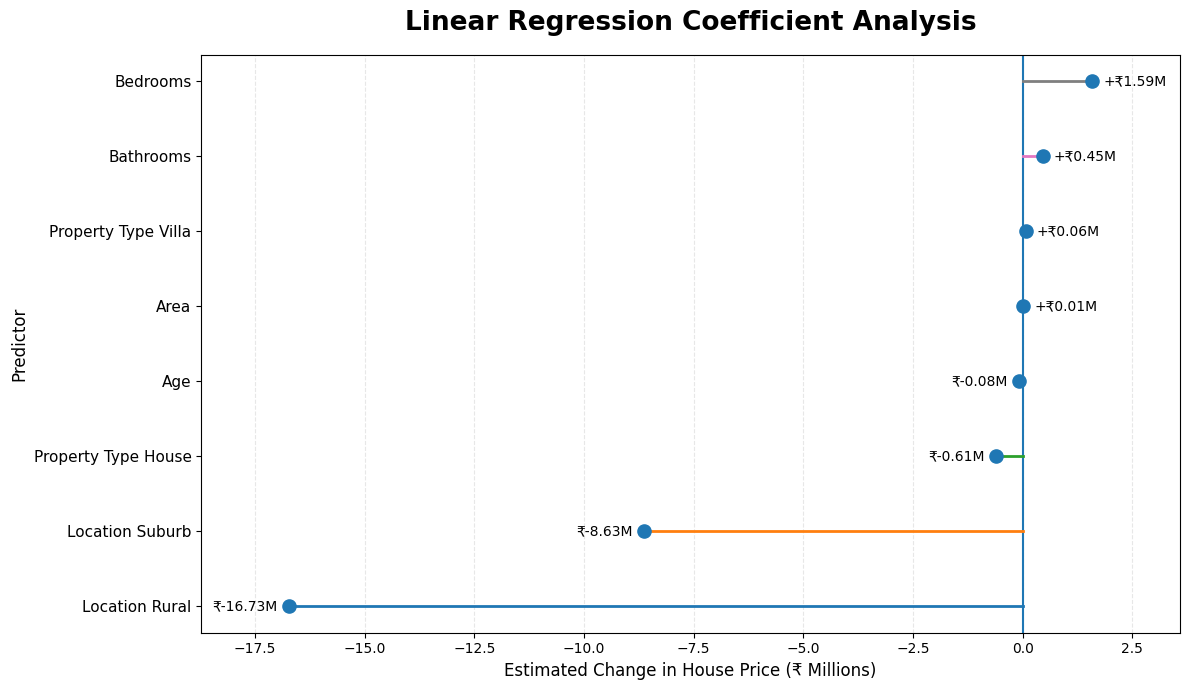

Coefficient dot plot saved successfully.


In [311]:
# ============================================
# 7.3 PROFESSIONAL COEFFICIENT DOT PLOT
# ============================================

import matplotlib.pyplot as plt
import numpy as np

coef_plot = coefficient_df.copy()

# Clean feature names
coef_plot["Feature"] = (
    coef_plot["Feature"]
    .str.replace("categorical__", "", regex=False)
    .str.replace("remainder__", "", regex=False)
    .str.replace("_", " ", regex=False)
)

# Convert coefficients to ₹ millions
coef_plot["Coefficient_Millions"] = (
    coef_plot["Coefficient"] / 1_000_000
)

# Sort from most negative to most positive
coef_plot = coef_plot.sort_values(
    "Coefficient_Millions"
).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 7))

y_pos = np.arange(len(coef_plot))

# Zero reference line
ax.axvline(
    0,
    linewidth=1.5
)

# Horizontal stems
for y, value in zip(
    y_pos,
    coef_plot["Coefficient_Millions"]
):
    ax.plot(
        [0, value],
        [y, y],
        linewidth=2
    )

# Coefficient points
ax.scatter(
    coef_plot["Coefficient_Millions"],
    y_pos,
    s=90,
    zorder=3
)

# Value labels
for y, value in zip(
    y_pos,
    coef_plot["Coefficient_Millions"]
):
    if value >= 0:
        ax.text(
            value + 0.25,
            y,
            f"+₹{value:.2f}M",
            va="center",
            fontsize=10
        )
    else:
        ax.text(
            value - 0.25,
            y,
            f"₹{value:.2f}M",
            va="center",
            ha="right",
            fontsize=10
        )

ax.set_yticks(y_pos)
ax.set_yticklabels(
    coef_plot["Feature"],
    fontsize=11
)

ax.set_title(
    "Linear Regression Coefficient Analysis",
    fontsize=19,
    fontweight="bold",
    pad=18
)

ax.set_xlabel(
    "Estimated Change in House Price (₹ Millions)",
    fontsize=12
)

ax.set_ylabel(
    "Predictor",
    fontsize=12
)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

ax.set_axisbelow(True)

# Give labels enough breathing room
xmin = coef_plot["Coefficient_Millions"].min()
xmax = coef_plot["Coefficient_Millions"].max()

ax.set_xlim(
    xmin - 2,
    xmax + 2
)

plt.tight_layout()

plt.savefig(
    "visualizations/08_linear_regression_coefficients.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Coefficient dot plot saved successfully.")

## 7.4 Permutation Feature Importance

Permutation importance is used to measure the practical contribution of each original predictor to model performance.

Each feature is randomly shuffled while the remaining features are kept unchanged. The resulting decrease in model performance indicates how strongly the feature contributes to the predictive capability of the model.

Unlike raw regression coefficients, permutation importance allows features with different units and categorical structures to be compared more directly.

In [312]:
# ============================================
# 7.4 PERMUTATION FEATURE IMPORTANCE
# ============================================

from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline

# Build complete preprocessing + model pipeline
model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

# Train pipeline on original training features
model_pipeline.fit(
    X_train,
    y_train_np
)

# Calculate permutation importance on unseen test data
perm_result = permutation_importance(
    model_pipeline,
    X_test,
    y_test_np,
    scoring="r2",
    n_repeats=30,
    random_state=42,
    n_jobs=-1
)

permutation_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance_Mean": perm_result.importances_mean,
    "Importance_Std": perm_result.importances_std
})

permutation_df = permutation_df.sort_values(
    "Importance_Mean",
    ascending=True
).reset_index(drop=True)

display(permutation_df)

,Feature,Importance_Mean,Importance_Std
0,Property_Type,0.00,0.00
1,Bathrooms,0.00,0.00
2,Age,0.02,0.01
3,Bedrooms,0.10,0.02
4,Location,0.70,0.08
5,Area,1.31,0.20


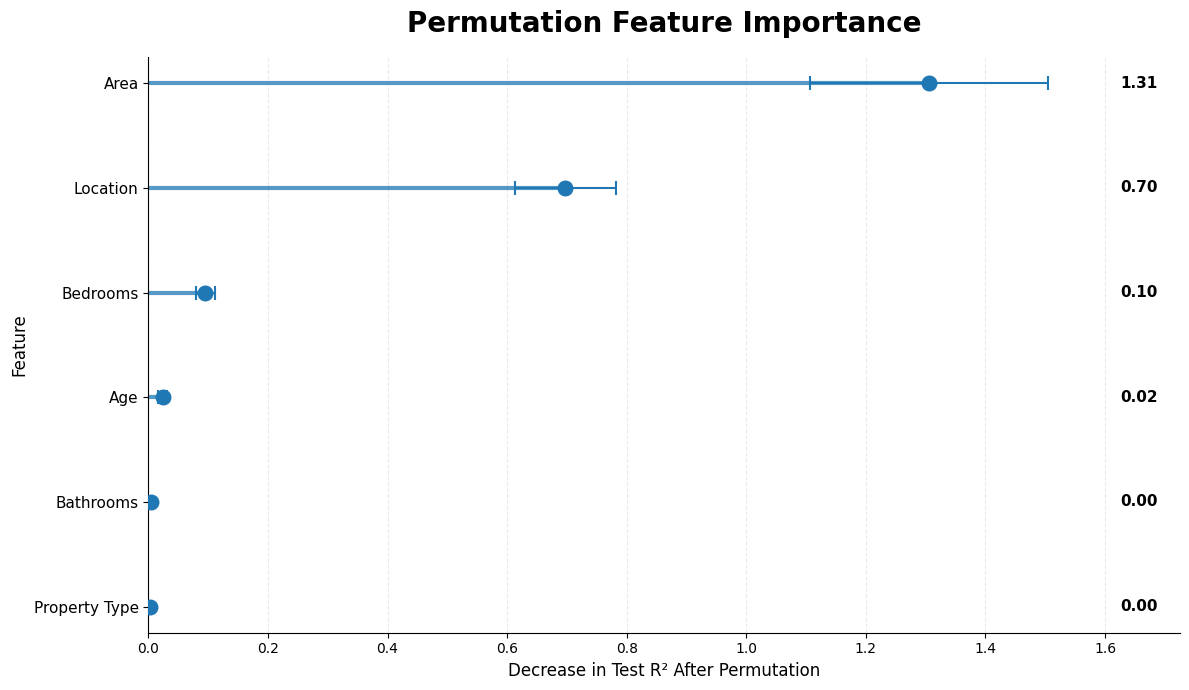

Final permutation feature importance visualization saved successfully.


In [313]:
# ============================================================
# 9.3 FINAL — PROFESSIONAL PERMUTATION FEATURE IMPORTANCE
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

perm_plot = (
    permutation_df
    .sort_values("Importance_Mean", ascending=True)
    .reset_index(drop=True)
)

# Clean feature names
perm_plot["Feature_Display"] = (
    perm_plot["Feature"]
    .str.replace("_", " ", regex=False)
)

features = perm_plot["Feature_Display"].values
importance = perm_plot["Importance_Mean"].values
std = perm_plot["Importance_Std"].values

y = np.arange(len(features))

fig, ax = plt.subplots(figsize=(12, 7))

# ------------------------------------------------------------
# Main stems
# ------------------------------------------------------------
for yi, value in zip(y, importance):
    ax.hlines(
        yi,
        0,
        value,
        linewidth=3,
        alpha=0.75
    )

# ------------------------------------------------------------
# Importance points
# ------------------------------------------------------------
ax.scatter(
    importance,
    y,
    s=110,
    zorder=3
)

# ------------------------------------------------------------
# Error bars
# ------------------------------------------------------------
ax.errorbar(
    importance,
    y,
    xerr=std,
    fmt="none",
    capsize=5,
    capthick=1.5,
    elinewidth=1.5,
    zorder=2
)

# ------------------------------------------------------------
# Fixed-position value labels
# ------------------------------------------------------------

label_x = max(importance + std) * 1.08

for yi, value in zip(y, importance):

    ax.text(
        label_x,
        yi,
        f"{value:.2f}",
        va="center",
        ha="left",
        fontsize=11,
        fontweight="bold"
    )

# ------------------------------------------------------------
# Axes
# ------------------------------------------------------------

ax.set_yticks(y)
ax.set_yticklabels(
    features,
    fontsize=11
)

ax.set_xlabel(
    "Decrease in Test R² After Permutation",
    fontsize=12
)

ax.set_ylabel(
    "Feature",
    fontsize=12
)

ax.set_title(
    "Permutation Feature Importance",
    fontsize=20,
    fontweight="bold",
    pad=18
)

# ------------------------------------------------------------
# Grid
# ------------------------------------------------------------

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

ax.set_axisbelow(True)

# Zero reference
ax.axvline(
    0,
    linewidth=1.2
)

# ------------------------------------------------------------
# Layout / spacing
# ------------------------------------------------------------

ax.set_xlim(
    0,
    label_x + 0.10
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

plt.savefig(
    "visualizations/09_permutation_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Final permutation feature importance visualization "
    "saved successfully."
)

## 10. Polynomial Regression

Polynomial Regression extends the Linear Regression framework by introducing polynomial terms of the numerical predictors.

The objective is to capture potential nonlinear relationships between property characteristics and house prices while maintaining a regression-based modelling framework.

The model will be evaluated on the same unseen test set using MAE, MSE, RMSE, and R².

## 10.1 Polynomial Regression — Feature Engineering

Polynomial Regression is used to capture nonlinear relationships between numerical property characteristics and house prices.

Only the numerical predictors are expanded into polynomial terms, while categorical variables remain one-hot encoded. This avoids unnecessary expansion of categorical dummy variables and keeps the model interpretable.

A polynomial degree of 2 is used to capture quadratic relationships while controlling model complexity.

In [314]:
# ============================================================
# 10.1 POLYNOMIAL REGRESSION — FEATURE PREPARATION
# ============================================================

from sklearn.preprocessing import PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

# Numerical and categorical features
numerical_features = [
    "Area",
    "Bedrooms",
    "Bathrooms",
    "Age"
]

categorical_features = [
    "Location",
    "Property_Type"
]

# Polynomial transformation for numerical variables only
polynomial_preprocessor = ColumnTransformer(
    transformers=[
        (
            "polynomial",
            PolynomialFeatures(
                degree=2,
                include_bias=False
            ),
            numerical_features
        ),
        (
            "categorical",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

# Polynomial Regression pipeline
polynomial_model = Pipeline([
    (
        "preprocessor",
        polynomial_preprocessor
    ),
    (
        "regressor",
        LinearRegression()
    )
])

print("Polynomial Regression pipeline created successfully.")
print("Polynomial Degree: 2")
print("Polynomial Features:", numerical_features)
print("Categorical Features:", categorical_features)

Polynomial Regression pipeline created successfully.
Polynomial Degree: 2
Polynomial Features: ['Area', 'Bedrooms', 'Bathrooms', 'Age']
Categorical Features: ['Location', 'Property_Type']


In [315]:
# ============================================================
# 10.2 TRAIN POLYNOMIAL REGRESSION
# ============================================================

# Train the polynomial regression model
polynomial_model.fit(
    X_train,
    y_train_np
)

print("Polynomial Regression trained successfully.")

# Generate predictions on unseen test data
y_pred_poly = polynomial_model.predict(X_test)

print("Number of predictions:", len(y_pred_poly))

Polynomial Regression trained successfully.
Number of predictions: 60


In [316]:
# ============================================================
# 10.3 POLYNOMIAL REGRESSION — MODEL EVALUATION
# ============================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Calculate evaluation metrics
mae_poly = mean_absolute_error(
    y_test_np,
    y_pred_poly
)

mse_poly = mean_squared_error(
    y_test_np,
    y_pred_poly
)

rmse_poly = np.sqrt(mse_poly)

r2_poly = r2_score(
    y_test_np,
    y_pred_poly
)

# Display results
print("POLYNOMIAL REGRESSION")
print("=" * 50)
print(f"MAE  : ₹{mae_poly:,.2f}")
print(f"MSE  : ₹{mse_poly:,.2f}")
print(f"RMSE : ₹{rmse_poly:,.2f}")
print(f"R²   : {r2_poly:.4f}")

POLYNOMIAL REGRESSION
MAE  : ₹2,367,902.24
MSE  : ₹10,116,153,891,351.46
RMSE : ₹3,180,590.18
R²   : 0.9290


In [317]:
# ============================================================
# 10.4 SAVE POLYNOMIAL REGRESSION RESULTS
# ============================================================

polynomial_results = pd.DataFrame({
    "Model": ["Polynomial Regression (Degree 2)"],
    "MAE": [mae_poly],
    "MSE": [mse_poly],
    "RMSE": [rmse_poly],
    "R2": [r2_poly]
})

polynomial_results.to_csv(
    "results/polynomial_regression_results.csv",
    index=False
)

display(polynomial_results)

print("Polynomial Regression results saved successfully.")

,Model,MAE,MSE,RMSE,R2
0,Polynomial Regression (Degree 2),"2,367,902.24","10,116,153,891,351.46","3,180,590.18",0.93


Polynomial Regression results saved successfully.


## 11. Decision Tree Regression

Decision Tree Regression models nonlinear relationships by recursively partitioning the feature space into increasingly homogeneous regions.

Unlike linear models, a decision tree can capture nonlinear relationships and feature interactions without requiring explicit polynomial transformations.

To reduce overfitting, the tree complexity will be controlled using a maximum depth.

In [318]:
# ============================================================
# 11.1 DECISION TREE REGRESSION
# ============================================================

from sklearn.tree import DecisionTreeRegressor

decision_tree_model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "regressor",
        DecisionTreeRegressor(
            max_depth=6,
            min_samples_split=10,
            min_samples_leaf=5,
            random_state=42
        )
    )
])

print("Decision Tree Regression pipeline created successfully.")
print("Maximum Depth       :", 6)
print("Minimum Samples Split:", 10)
print("Minimum Samples Leaf :", 5)

Decision Tree Regression pipeline created successfully.
Maximum Depth       : 6
Minimum Samples Split: 10
Minimum Samples Leaf : 5


In [319]:
# ============================================================
# 11.2 TRAIN DECISION TREE REGRESSION
# ============================================================

decision_tree_model.fit(
    X_train,
    y_train_np
)

print("Decision Tree Regression trained successfully.")

# Generate predictions on unseen test data
y_pred_tree = decision_tree_model.predict(X_test)

print("Number of predictions:", len(y_pred_tree))

Decision Tree Regression trained successfully.
Number of predictions: 60


In [320]:
# ============================================================
# 11.3 DECISION TREE — MODEL EVALUATION
# ============================================================

mae_tree = mean_absolute_error(
    y_test_np,
    y_pred_tree
)

mse_tree = mean_squared_error(
    y_test_np,
    y_pred_tree
)

rmse_tree = np.sqrt(mse_tree)

r2_tree = r2_score(
    y_test_np,
    y_pred_tree
)

print("DECISION TREE REGRESSION")
print("=" * 50)
print(f"MAE  : ₹{mae_tree:,.2f}")
print(f"MSE  : ₹{mse_tree:,.2f}")
print(f"RMSE : ₹{rmse_tree:,.2f}")
print(f"R²   : {r2_tree:.4f}")

DECISION TREE REGRESSION
MAE  : ₹2,588,829.20
MSE  : ₹10,846,294,140,743.33
RMSE : ₹3,293,371.24
R²   : 0.9238


In [321]:
# ============================================================
# 11.4 SAVE DECISION TREE RESULTS
# ============================================================

decision_tree_results = pd.DataFrame({
    "Model": ["Decision Tree Regression"],
    "MAE": [mae_tree],
    "MSE": [mse_tree],
    "RMSE": [rmse_tree],
    "R2": [r2_tree]
})

decision_tree_results.to_csv(
    "results/decision_tree_results.csv",
    index=False
)

display(decision_tree_results)

print("Decision Tree results saved successfully.")

,Model,MAE,MSE,RMSE,R2
0,Decision Tree Regression,"2,588,829.20","10,846,294,140,743.33","3,293,371.24",0.92


Decision Tree results saved successfully.


## 12. Random Forest Regression

Random Forest Regression is an ensemble learning method that combines predictions from multiple decision trees.

Each tree is trained using randomized samples and feature selections, and their predictions are aggregated to improve generalization and reduce the variance associated with a single decision tree.

The model will be evaluated using the same unseen test set and metrics used for all previous models.

In [322]:
# ============================================================
# 12.1 RANDOM FOREST REGRESSION
# ============================================================

from sklearn.ensemble import RandomForestRegressor

random_forest_model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "regressor",
        RandomForestRegressor(
            n_estimators=300,
            max_depth=8,
            min_samples_split=5,
            min_samples_leaf=2,
            max_features="sqrt",
            random_state=42,
            n_jobs=-1
        )
    )
])

print("Random Forest Regression pipeline created successfully.")
print("Number of Trees     :", 300)
print("Maximum Depth       :", 8)
print("Minimum Samples Split:", 5)
print("Minimum Samples Leaf :", 2)
print("Max Features        :", "sqrt")

Random Forest Regression pipeline created successfully.
Number of Trees     : 300
Maximum Depth       : 8
Minimum Samples Split: 5
Minimum Samples Leaf : 2
Max Features        : sqrt


In [323]:
# ============================================================
# 12.2 TRAIN RANDOM FOREST REGRESSION
# ============================================================

random_forest_model.fit(
    X_train,
    y_train_np
)

print("Random Forest Regression trained successfully.")

# Generate predictions on unseen test data
y_pred_rf = random_forest_model.predict(X_test)

print("Number of predictions:", len(y_pred_rf))

Random Forest Regression trained successfully.
Number of predictions: 60


In [324]:
# ============================================================
# 12.3 RANDOM FOREST — MODEL EVALUATION
# ============================================================

mae_rf = mean_absolute_error(
    y_test_np,
    y_pred_rf
)

mse_rf = mean_squared_error(
    y_test_np,
    y_pred_rf
)

rmse_rf = np.sqrt(mse_rf)

r2_rf = r2_score(
    y_test_np,
    y_pred_rf
)

print("RANDOM FOREST REGRESSION")
print("=" * 50)
print(f"MAE  : ₹{mae_rf:,.2f}")
print(f"MSE  : ₹{mse_rf:,.2f}")
print(f"RMSE : ₹{rmse_rf:,.2f}")
print(f"R²   : {r2_rf:.4f}")

RANDOM FOREST REGRESSION
MAE  : ₹3,684,313.62
MSE  : ₹23,182,820,406,988.07
RMSE : ₹4,814,854.14
R²   : 0.8372


In [325]:
# ============================================================
# 12.4 SAVE RANDOM FOREST RESULTS
# ============================================================

random_forest_results = pd.DataFrame({
    "Model": ["Random Forest Regression"],
    "MAE": [mae_rf],
    "MSE": [mse_rf],
    "RMSE": [rmse_rf],
    "R2": [r2_rf]
})

random_forest_results.to_csv(
    "results/random_forest_results.csv",
    index=False
)

display(random_forest_results)

print("Random Forest results saved successfully.")

,Model,MAE,MSE,RMSE,R2
0,Random Forest Regression,"3,684,313.62","23,182,820,406,988.07","4,814,854.14",0.84


Random Forest results saved successfully.


## 12.5 Random Forest Hyperparameter Optimization

The initial Random Forest configuration produced weaker test performance than the simpler regression models.

To determine whether this is caused by suboptimal hyperparameters, Randomized Search with 5-fold cross-validation will be performed using only the training data.

The final test set remains completely unseen during hyperparameter optimization. The best configuration will then be evaluated once on the test set.

In [326]:
# ============================================================
# 12.5 RANDOM FOREST HYPERPARAMETER OPTIMIZATION
# ============================================================

from sklearn.model_selection import RandomizedSearchCV

# Random Forest pipeline for tuning
rf_tuning_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "regressor",
        RandomForestRegressor(
            random_state=42,
            n_jobs=-1
        )
    )
])

# Hyperparameter search space
rf_param_grid = {
    "regressor__n_estimators": [200, 300, 500],
    "regressor__max_depth": [None, 6, 8, 10, 12],
    "regressor__min_samples_split": [2, 5, 10],
    "regressor__min_samples_leaf": [1, 2, 4],
    "regressor__max_features": [1.0, "sqrt"]
}

# Randomized cross-validation search
rf_random_search = RandomizedSearchCV(
    estimator=rf_tuning_pipeline,
    param_distributions=rf_param_grid,
    n_iter=20,
    scoring="neg_root_mean_squared_error",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# IMPORTANT:
# Search is performed ONLY on training data
rf_random_search.fit(
    X_train,
    y_train_np
)

print("\nRandom Forest hyperparameter tuning completed.")

print("\nBest Parameters:")
for parameter, value in rf_random_search.best_params_.items():
    print(f"{parameter}: {value}")

print(
    f"\nBest Cross-Validated RMSE: "
    f"₹{-rf_random_search.best_score_:,.2f}"
)

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Random Forest hyperparameter tuning completed.

Best Parameters:
regressor__n_estimators: 300
regressor__min_samples_split: 2
regressor__min_samples_leaf: 2
regressor__max_features: 1.0
regressor__max_depth: 12

Best Cross-Validated RMSE: ₹2,188,687.95


In [327]:
# ============================================================
# 12.6 FINAL OPTIMIZED RANDOM FOREST EVALUATION
# ============================================================

# Best model selected using training-set cross-validation
best_rf_model = rf_random_search.best_estimator_

# Predict on the completely unseen test set
y_pred_rf_tuned = best_rf_model.predict(X_test)

# Calculate final test metrics
mae_rf_tuned = mean_absolute_error(
    y_test_np,
    y_pred_rf_tuned
)

mse_rf_tuned = mean_squared_error(
    y_test_np,
    y_pred_rf_tuned
)

rmse_rf_tuned = np.sqrt(mse_rf_tuned)

r2_rf_tuned = r2_score(
    y_test_np,
    y_pred_rf_tuned
)

print("OPTIMIZED RANDOM FOREST REGRESSION")
print("=" * 55)
print(f"MAE  : ₹{mae_rf_tuned:,.2f}")
print(f"MSE  : ₹{mse_rf_tuned:,.2f}")
print(f"RMSE : ₹{rmse_rf_tuned:,.2f}")
print(f"R²   : {r2_rf_tuned:.4f}")

OPTIMIZED RANDOM FOREST REGRESSION
MAE  : ₹1,611,259.09
MSE  : ₹4,923,749,816,934.83
RMSE : ₹2,218,952.41
R²   : 0.9654


In [328]:
# ============================================================
# 12.7 SAVE OPTIMIZED RANDOM FOREST RESULTS
# ============================================================

import pandas as pd

optimized_rf_results = pd.DataFrame({
    "Model": ["Optimized Random Forest Regression"],
    "MAE": [mae_rf_tuned],
    "MSE": [mse_rf_tuned],
    "RMSE": [rmse_rf_tuned],
    "R2": [r2_rf_tuned]
})

optimized_rf_results.to_csv(
    "results/optimized_random_forest_results.csv",
    index=False
)

display(optimized_rf_results)

print("Optimized Random Forest results saved successfully.")

,Model,MAE,MSE,RMSE,R2
0,Optimized Random Forest Regression,"1,611,259.09","4,923,749,816,934.83","2,218,952.41",0.97


Optimized Random Forest results saved successfully.


## 13. Final Model Diagnostics

The optimized Random Forest Regression model achieved the best predictive performance among the evaluated models. The following diagnostic visualizations assess its prediction accuracy and error behavior on the unseen test dataset.

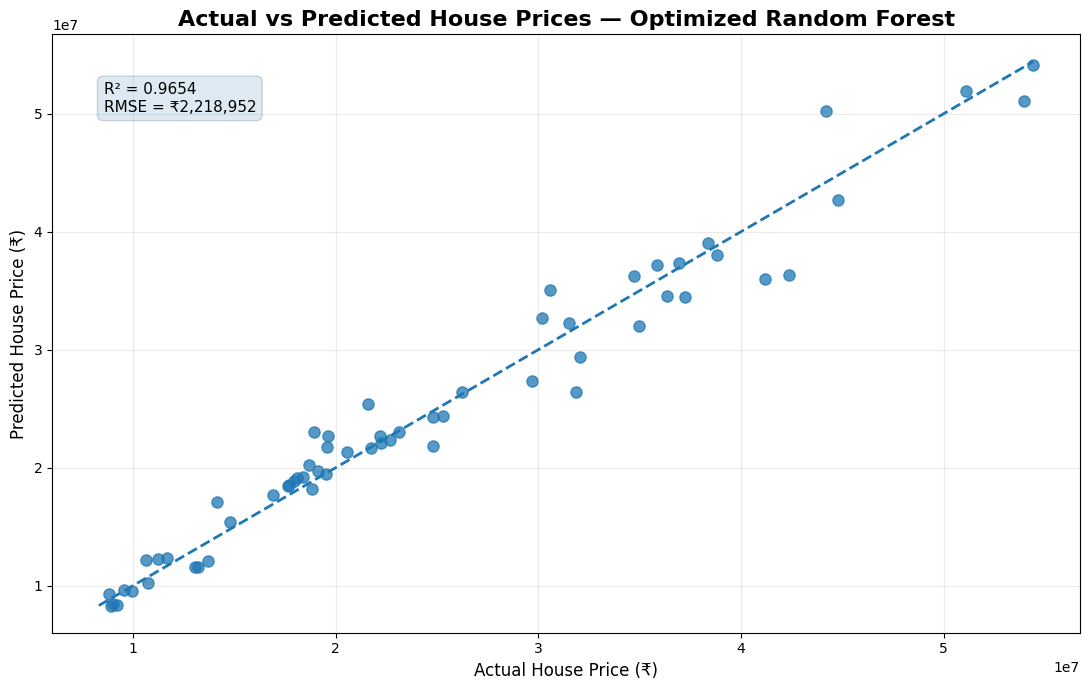

Actual vs predicted visualization saved successfully.


In [329]:
# ============================================================
# 13.1 ACTUAL VS PREDICTED PRICE
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(11, 7))

plt.scatter(
    y_test_np,
    y_pred_rf_tuned,
    alpha=0.75,
    s=65
)

# Perfect prediction reference line
min_price = min(y_test_np.min(), y_pred_rf_tuned.min())
max_price = max(y_test_np.max(), y_pred_rf_tuned.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--",
    linewidth=2
)

plt.title(
    "Actual vs Predicted House Prices — Optimized Random Forest",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Actual House Price (₹)", fontsize=12)
plt.ylabel("Predicted House Price (₹)", fontsize=12)

plt.text(
    0.05,
    0.92,
    f"R² = {r2_rf_tuned:.4f}\nRMSE = ₹{rmse_rf_tuned:,.0f}",
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment="top",
    bbox=dict(boxstyle="round,pad=0.4", alpha=0.15)
)

plt.grid(alpha=0.25)
plt.tight_layout()

plt.savefig(
    "visualizations/08_actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Actual vs predicted visualization saved successfully.")

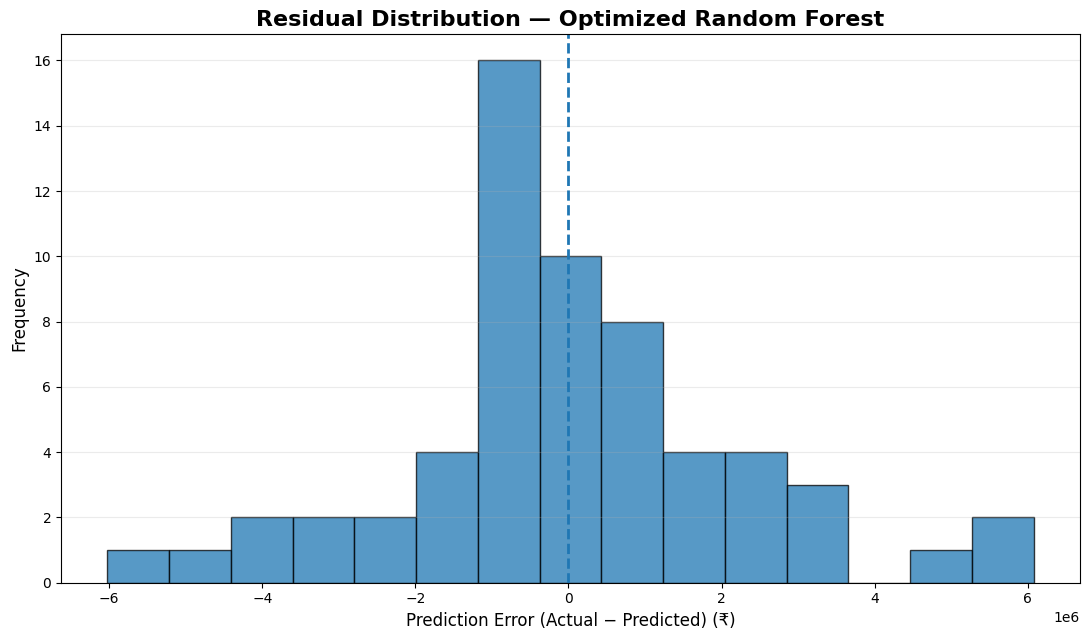

Residual distribution visualization saved successfully.


In [330]:
# ============================================================
# 13.2 RESIDUAL DISTRIBUTION
# ============================================================

residuals_rf = y_test_np - y_pred_rf_tuned

plt.figure(figsize=(11, 6.5))

plt.hist(
    residuals_rf,
    bins=15,
    edgecolor="black",
    alpha=0.75
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=2
)

plt.title(
    "Residual Distribution — Optimized Random Forest",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Prediction Error (Actual − Predicted) (₹)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    "visualizations/09_residual_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Residual distribution visualization saved successfully.")

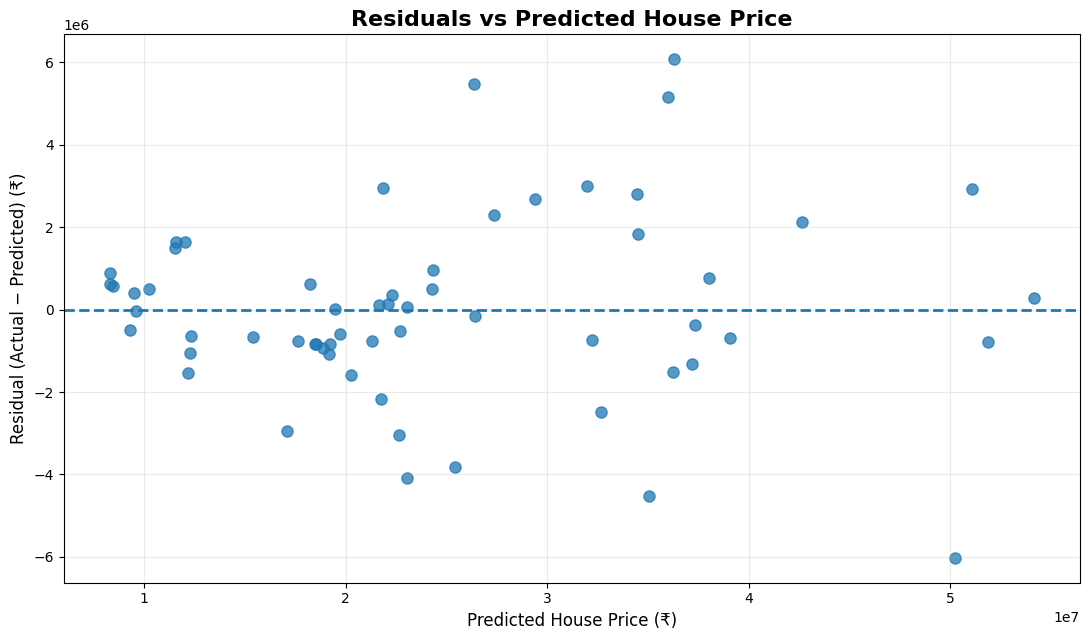

Residuals vs predicted visualization saved successfully.


In [331]:
# ============================================================
# 13.3 RESIDUALS VS PREDICTED PRICE
# ============================================================

plt.figure(figsize=(11, 6.5))

plt.scatter(
    y_pred_rf_tuned,
    residuals_rf,
    alpha=0.75,
    s=65
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=2
)

plt.title(
    "Residuals vs Predicted House Price",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Predicted House Price (₹)", fontsize=12)
plt.ylabel("Residual (Actual − Predicted) (₹)", fontsize=12)

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    "visualizations/10_residuals_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Residuals vs predicted visualization saved successfully.")

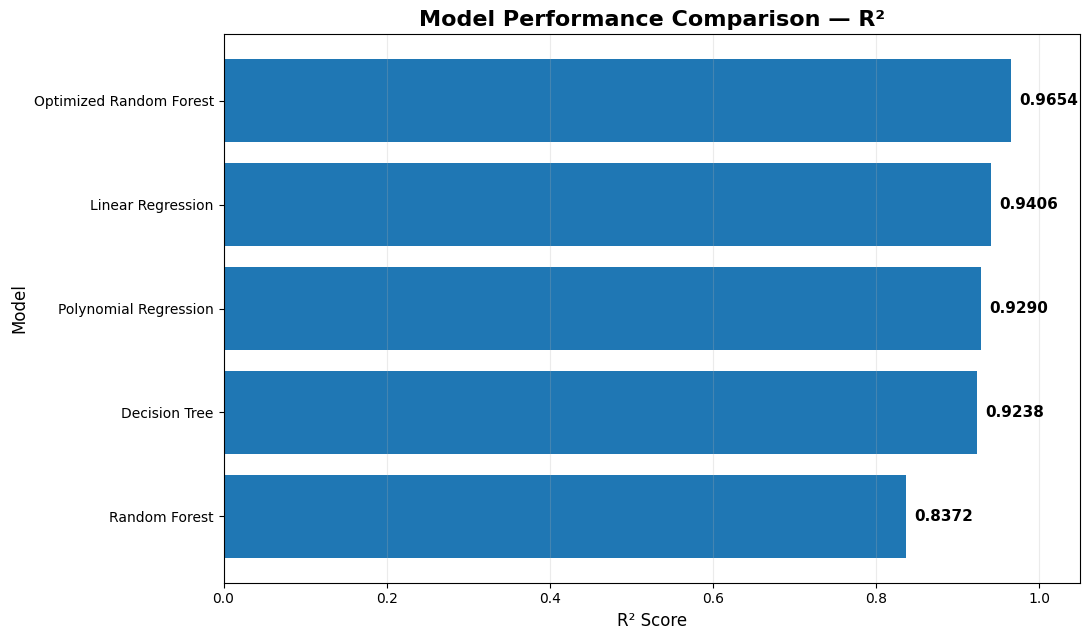

Final model comparison visualization saved successfully.


In [332]:
# ============================================================
# 14. FINAL MODEL COMPARISON — R²
# ============================================================

model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Polynomial Regression",
        "Decision Tree",
        "Random Forest",
        "Optimized Random Forest"
    ],
    "R2": [
        r2_scratch,
        r2_poly,
        r2_tree,
        r2_rf,
        r2_rf_tuned
    ]
}).sort_values("R2", ascending=True)

plt.figure(figsize=(11, 6.5))

bars = plt.barh(
    model_comparison["Model"],
    model_comparison["R2"]
)

plt.xlabel("R² Score", fontsize=12)
plt.ylabel("Model", fontsize=12)

plt.title(
    "Model Performance Comparison — R²",
    fontsize=16,
    fontweight="bold"
)

plt.xlim(0, 1.05)

# Add values at the end of each bar
for bar, value in zip(bars, model_comparison["R2"]):
    plt.text(
        value + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.4f}",
        va="center",
        fontsize=11,
        fontweight="bold"
    )

plt.grid(
    axis="x",
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    "visualizations/11_model_r2_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Final model comparison visualization saved successfully.")

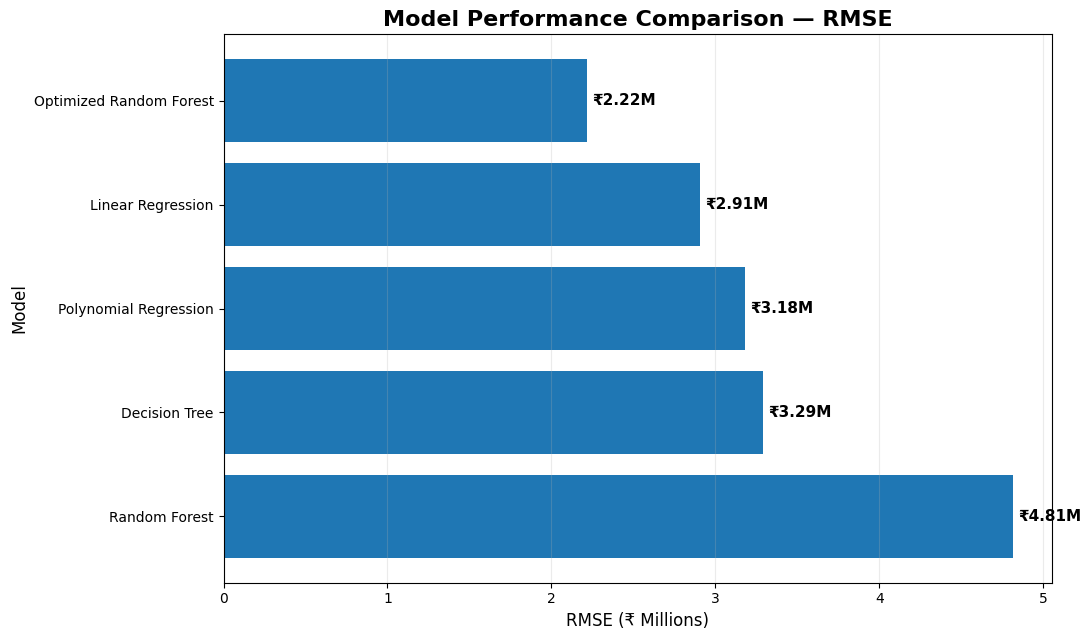

RMSE comparison visualization saved successfully.


In [333]:
# ============================================================
# FINAL MODEL COMPARISON — RMSE
# ============================================================

model_rmse_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Polynomial Regression",
        "Decision Tree",
        "Random Forest",
        "Optimized Random Forest"
    ],
    "RMSE": [
        rmse_scratch,
        rmse_poly,
        rmse_tree,
        rmse_rf,
        rmse_rf_tuned
    ]
}).sort_values("RMSE", ascending=False)

plt.figure(figsize=(11, 6.5))

bars = plt.barh(
    model_rmse_comparison["Model"],
    model_rmse_comparison["RMSE"] / 1_000_000
)

plt.xlabel("RMSE (₹ Millions)", fontsize=12)
plt.ylabel("Model", fontsize=12)

plt.title(
    "Model Performance Comparison — RMSE",
    fontsize=16,
    fontweight="bold"
)

# Value labels
for bar, value in zip(
    bars,
    model_rmse_comparison["RMSE"]
):
    plt.text(
        value / 1_000_000 + 0.03,
        bar.get_y() + bar.get_height() / 2,
        f"₹{value / 1_000_000:.2f}M",
        va="center",
        fontsize=11,
        fontweight="bold"
    )

plt.grid(
    axis="x",
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    "visualizations/model_rmse_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("RMSE comparison visualization saved successfully.")

## 15. Model Interpretation and Key Findings

The optimized Random Forest Regression model achieved the strongest predictive performance among all evaluated models, with an R² of 0.9654 and an RMSE of approximately ₹2.22 million on the unseen test dataset.

The analysis of feature relationships, permutation importance, regression coefficients, and model diagnostics provides additional insight into the factors influencing house prices.

The following findings summarize the major patterns identified throughout the analysis.

### Key Findings

1. **Property Area is the strongest numerical predictor of house price.**
   The Pearson correlation between Area and Price is approximately 0.80, indicating a strong positive relationship. Larger properties generally command higher prices.

2. **Location has a substantial influence on property prices.**
   City Center properties have the highest average prices, followed by Suburban and Rural properties. Area–Price relationships are also strong within each location category.

3. **Bedrooms have a moderate positive relationship with price.**
   The correlation between Bedrooms and Price is approximately 0.20. Properties with more bedrooms generally tend to have higher prices, although the relationship is considerably weaker than that of Area.

4. **Property age has a weak negative relationship with price.**
   Age and Price have a correlation of approximately −0.13, suggesting that older properties tend to have slightly lower prices, although age is not a dominant predictor.

5. **Bathrooms show very little linear correlation with price.**
   The correlation between Bathrooms and Price is approximately −0.03. This indicates that the number of bathrooms alone does not explain much of the variation in price in this dataset.

6. **Area and Location dominate permutation importance.**
   Permutation importance identified Area as the most influential feature, followed by Location and Bedrooms.

7. **Hyperparameter optimization substantially improved Random Forest performance.**
   The initial Random Forest achieved an R² of 0.8372, whereas the optimized Random Forest achieved an R² of 0.9654. This demonstrates the importance of appropriate model configuration.

8. **The optimized Random Forest was selected as the final model.**
   It achieved the highest R² and the lowest RMSE among the evaluated models, making it the most suitable model for house-price prediction within this dataset.

## 16. Conclusion and Recommendations

### 16.1 Overall Conclusion

This project analyzed a residential house-price dataset containing 300 property records and developed multiple regression models to predict house prices.

The exploratory analysis identified property Area and Location as the most important factors associated with house prices. Area showed a strong positive correlation with Price (Pearson r ≈ 0.80), while Location demonstrated substantial differences in average property prices.

Several regression approaches were evaluated, including Linear Regression, Polynomial Regression, Decision Tree Regression, and Random Forest Regression. The initial Random Forest model performed relatively poorly; however, hyperparameter optimization substantially improved its predictive performance.

The optimized Random Forest Regression model achieved the best overall performance on the unseen test dataset:

- R² = 0.9654
- RMSE = approximately ₹2.22 million
- MAE = approximately ₹1.61 million

Based on these results, the optimized Random Forest was selected as the final predictive model.

### 16.2 Business Recommendations

The findings provide several useful insights for property pricing and decision-making:

1. **Consider property area as a major pricing factor.**  
   Larger properties generally command higher prices and should be carefully considered when estimating property value.

2. **Account for location when estimating prices.**  
   Location produced substantial differences in average house prices, making it an important factor for property valuation.

3. **Use multiple property characteristics together.**  
   Price prediction should not rely on a single feature. Combining area, bedrooms, bathrooms, age, location, and property type provides a more comprehensive valuation approach.

4. **Use the optimized Random Forest for predictive applications.**  
   Within this dataset, the optimized model provided the best predictive performance among the evaluated approaches.

5. **Use predictions as estimates rather than exact valuations.**  
   Even the best model produces prediction errors, particularly for some higher-priced properties. Predictions should therefore support decision-making rather than replace professional property valuation.

### 16.3 Limitations

This analysis has several limitations:

- The dataset contains only 300 observations, which limits the generalizability of the results.
- The available features may not capture all factors affecting house prices.
- External factors such as neighborhood development, proximity to amenities, economic conditions, and market trends were not included.
- Model performance was evaluated using a single held-out test set.
- The dataset may not represent the broader housing market.

### 16.4 Future Scope

Future work could improve the project by:

- Collecting a larger and more diverse dataset.
- Adding additional features such as distance to schools, hospitals, transportation, and commercial areas.
- Incorporating location-based geographic features.
- Testing additional ensemble and boosting algorithms.
- Performing more extensive hyperparameter optimization.
- Using cross-validation and repeated experiments to obtain more robust performance estimates.
- Deploying the optimized model as a web or application-based house-price prediction system.